# HERMES-style amplitude analysis with Hessian uncertainties

This is the non-bootstrap counterpart of the amplitude notebook.  For every
reaction/bin file it selects the global minimum from the (N) ordinary
minimisations, then plots the amplitude point and the covariance belonging to
that same entry.  The established four-by-four HERMES scaling block is retained.

In [7]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import ROOT

try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

# A working LaTeX installation is required, as requested for all plots.
mpl.rcParams["text.usetex"] = False
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 2.0,
    "axes.linewidth": 1.4,
    "savefig.dpi": 1200,
})

COLORS = {
    "fit": "#0072B2",
    "official": "#D55E00",
    "neutral": "#333333",
    "accent": "#009E73",
}

MAG_RE = re.compile(r"^[ab]_[TL]_\d+_(?:m?\d+)$")
PHASE_RE = re.compile(r"^[ab]phi_[TL]_\d+_(?:m?\d+)$")
RESULT_RE = re.compile(
    r"(?P<beam>El|Mu)(?P<particle>Rho|Omega|Phi)_results_(?P<bin>\d+)$"
)


def style_axis(ax, grid=False):
    ax.minorticks_on()
    ax.tick_params(which="major", direction="in", top=True, right=True,
                   length=7, width=1.2, pad=5)
    ax.tick_params(which="minor", direction="in", top=True, right=True,
                   length=3.5, width=0.9)
    if grid:
        ax.grid(True, color="0.90", linewidth=0.8, zorder=0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.3)


def save_figure(fig, output_path, show=True):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    print(f"Saved {output_path.resolve()}")


def dataset_metadata(path):
    path = Path(path)
    match = RESULT_RE.match(path.stem)
    if not match:
        return {"key": path.stem, "title": path.stem, "bin": None}
    info = match.groupdict()
    beam = {"El": r"e^-", "Mu": r"\mu^-"}[info["beam"]]
    particle = {"Rho": r"\rho^0", "Omega": r"\omega", "Phi": r"\phi"}[info["particle"]]
    return {
        "key": path.stem,
        "title": rf"${beam}{particle}$, bin {info['bin']}",
        "beam": info["beam"],
        "particle": info["particle"],
        "bin": int(info["bin"]),
    }


def list_root_branches(path, tree_name="fitResults"):
    path = Path(path).expanduser().resolve()
    root_file = ROOT.TFile.Open(str(path), "READ")
    if not root_file or root_file.IsZombie():
        raise OSError(f"Could not open ROOT file: {path}")
    try:
        tree = root_file.Get(tree_name)
        if not tree:
            raise KeyError(f"Tree {tree_name!r} not found in {path}")
        return [str(branch.GetName()) for branch in tree.GetListOfBranches()]
    finally:
        root_file.Close()


def read_fit_file(path, tree_name="fitResults"):
    path = Path(path).expanduser().resolve()
    if not path.exists():
        raise FileNotFoundError(path)
    branches = list_root_branches(path, tree_name)
    rdf = ROOT.RDataFrame(tree_name, str(path))
    arrays = rdf.AsNumpy(columns=branches)
    frame = pd.DataFrame({name: np.asarray(values) for name, values in arrays.items()})
    if frame.empty:
        raise RuntimeError(f"No minimisation entries in {path}")
    return frame


def objective_column(frame):
    for candidate in ("chi2", "val", "log_val"):
        if candidate in frame:
            return candidate
    raise KeyError("No objective branch found (expected chi2, val, or log_val)")


def select_best_minimum(frame, require_accurate_covariance=True):
    objective = objective_column(frame)
    values = pd.to_numeric(frame[objective], errors="coerce").to_numpy(dtype=float)
    usable = np.isfinite(values)
    if "fit_ok" in frame:
        usable &= frame["fit_ok"].astype(bool).to_numpy()
    if "status" in frame:
        usable &= frame["status"].to_numpy() == 0
    if not np.any(usable):
        raise RuntimeError("No converged minimisation has a finite objective value")
    candidates = np.flatnonzero(usable)
    index = int(candidates[np.argmin(values[candidates])])
    row = frame.iloc[index].copy()

    required = ["hesse_ok", "cov_status"]
    missing = [name for name in required if name not in frame]
    if missing:
        raise KeyError(
            "This results file predates Hessian persistence; missing " + ", ".join(missing)
        )
    if not bool(row["hesse_ok"]):
        raise RuntimeError(f"The global minimum at entry {index} has no valid HESSE result")
    minimum_cov_status = 2 if require_accurate_covariance else 1
    if int(row["cov_status"]) < minimum_cov_status:
        raise RuntimeError(
            f"The global minimum at entry {index} has covariance status "
            f"{int(row['cov_status'])}; require >= {minimum_cov_status}"
        )
    return index, row, objective


def magnitude_parameters(columns):
    return [name for name in columns if MAG_RE.match(name)]


def phase_for_magnitude(name):
    return name[0] + "phi" + name[1:]


def amplitude_pairs(columns):
    available = set(columns)
    return [(name, phase_for_magnitude(name))
            for name in magnitude_parameters(columns)
            if phase_for_magnitude(name) in available]


def covariance_value(row, first, second):
    candidates = [f"cov__{first}__{second}", f"cov__{second}__{first}"]
    for branch in candidates:
        if branch in row.index:
            return float(row[branch])
    if first == second and f"err__{first}" in row.index:
        return float(row[f"err__{first}"]) ** 2
    return np.nan


def covariance_matrix(row, parameters):
    matrix = np.full((len(parameters), len(parameters)), np.nan)
    for i, first in enumerate(parameters):
        for j, second in enumerate(parameters):
            matrix[i, j] = covariance_value(row, first, second)
    return matrix


def transformed_argand_covariance(magnitude, phase, covariance_mag_phase):
    jacobian = np.array([
        [np.cos(phase), -magnitude * np.sin(phase)],
        [np.sin(phase),  magnitude * np.cos(phase)],
    ])
    return jacobian @ covariance_mag_phase @ jacobian.T


def add_covariance_ellipse(ax, centre, covariance, color, n_sigma=1.0, linewidth=2.2):
    covariance = np.asarray(covariance, dtype=float)
    if covariance.shape != (2, 2) or not np.isfinite(covariance).all():
        return
    covariance = 0.5 * (covariance + covariance.T)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    if np.any(eigenvalues < -1e-12):
        return
    eigenvalues = np.clip(eigenvalues, 0.0, None)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2.0 * n_sigma * np.sqrt(eigenvalues)
    ellipse = Ellipse(centre, width, height, angle=angle,
                      facecolor=(color,0.22), edgecolor=(color,1),
                      linewidth=linewidth)
    ax.add_patch(ellipse)


def wave_label(name):
    match = re.match(r"(?P<refl>[ab])_(?P<pol>[TL])_(?P<ell>\d+)_(?P<m>m?\d+)", name)
    if not match:
        return name.replace("_", r"\_")
    info = match.groupdict()
    reflection = "+" if info["refl"] == "a" else "-"
    wave = {"0": "S", "1": "P"}.get(info["ell"], rf"\ell={info['ell']}")
    m = info["m"].replace("m", "-")
    return rf"${wave}^{{{reflection}}}_{{\mathrm{{{info['pol']}}}{m}}}$"


def discover_result_files(root_dir):
    root_dir = Path(root_dir).expanduser()
    files = []
    for beam in ("El", "Mu"):
        for particle in ("Rho", "Omega", "Phi"):
            files.extend(root_dir.glob(f"{beam}{particle}_results_*.root"))
    return sorted({path.resolve() for path in files}, key=lambda path: path.name)


In [8]:
OUTPUT_DIR = Path(
    "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles"
).expanduser()
FIGURE_DIR = Path("outputs/experimental_analysis_hessian")
TREE_NAME = "fitResults"
REQUIRE_ACCURATE_COVARIANCE = True

CHANNELS = [
    dict(key="e_rho", prefix="ElRho", title=r"$e^-\rho^0$",
         q2=np.array([0.82, 1.19, 1.66, 3.06]), W=4.8),
    dict(key="mu_rho", prefix="MuRho", title=r"$\mu^-\rho^0$",
         q2=np.array([1.14, 1.60, 2.80, 6.02]), W=9.9),
    dict(key="e_omega", prefix="ElOmega", title=r"$e^-\omega$",
         q2=np.array([1.28, 2.00, 4.00]), W=4.8),
    dict(key="mu_omega", prefix="MuOmega", title=r"$\mu^-\omega$",
         q2=np.array([1.16, 1.64, 3.58]), W=7.6),
    dict(key="e_phi", prefix="ElPhi", title=r"$e^-\phi$",
         q2=np.array([1.20, 1.70, 4.50]), W=np.sqrt(21.89)),
]

MAGNITUDES = [
    "a_T_1_1", "a_T_1_0", "a_T_1_m1", "a_T_0_0",
    "b_T_1_1", "b_T_1_0", "b_T_1_m1", "b_T_0_0",
    "a_L_1_1", "a_L_1_0", "a_L_1_m1", "a_L_0_0",
    "b_L_1_1", "b_L_1_0", "b_L_1_m1", "b_L_0_0",
]
PHASES = [phase_for_magnitude(name) for name in MAGNITUDES]
GROUP_TITLES = [
    "Natural transverse", "Unnatural transverse",
    "Natural longitudinal", "Unnatural longitudinal",
]


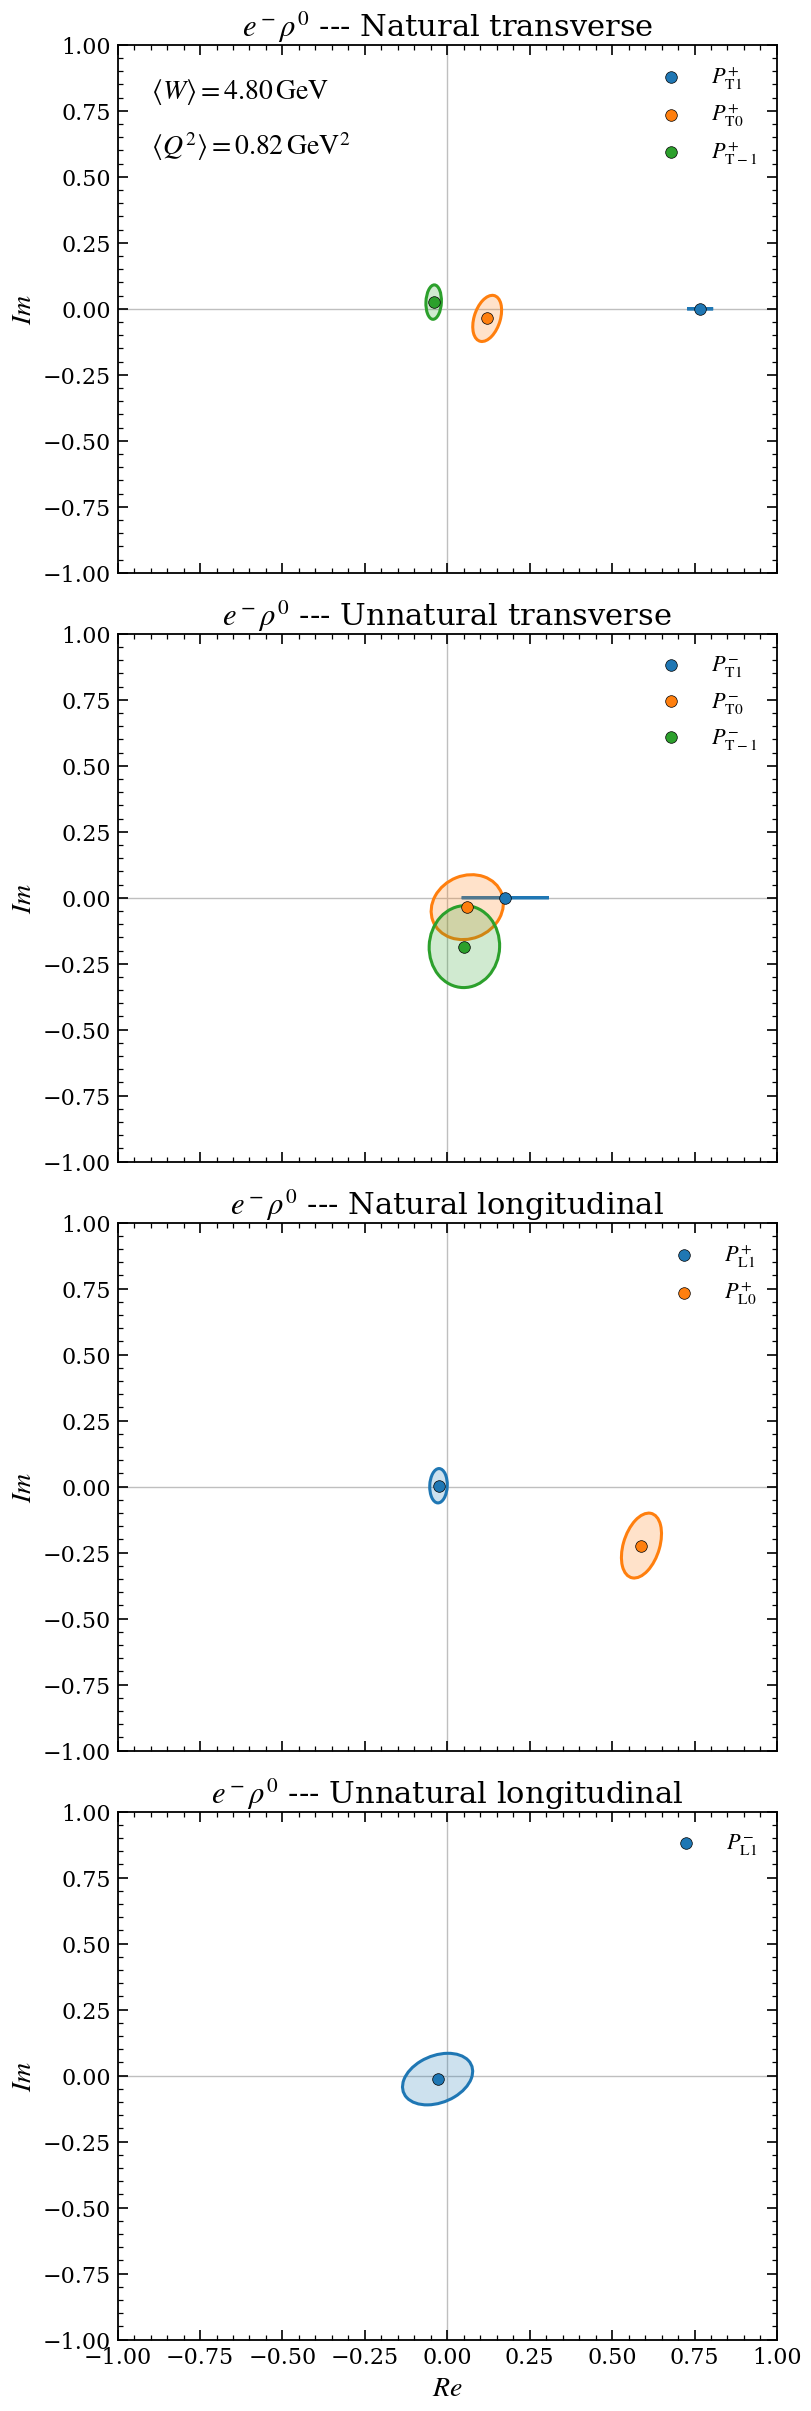

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_rho/ElRho_results_0_hessian_argand_poster.pdf


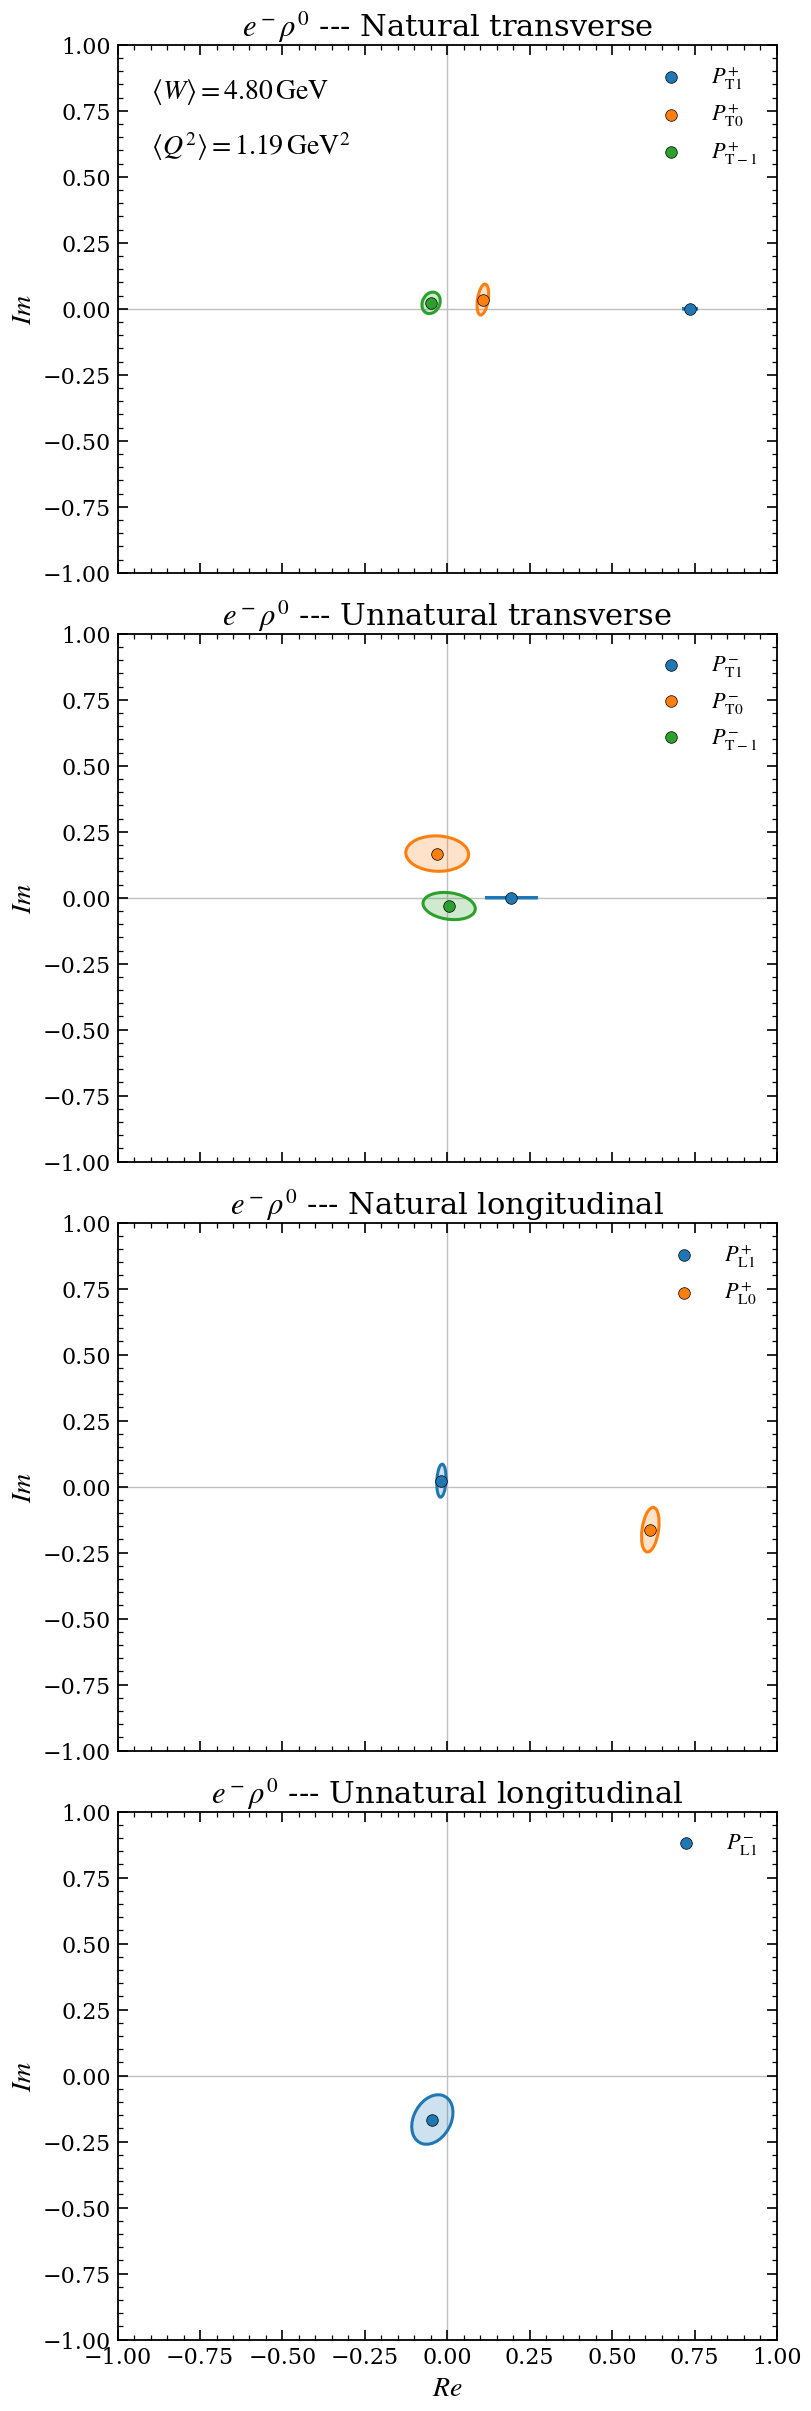

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_rho/ElRho_results_1_hessian_argand_poster.pdf


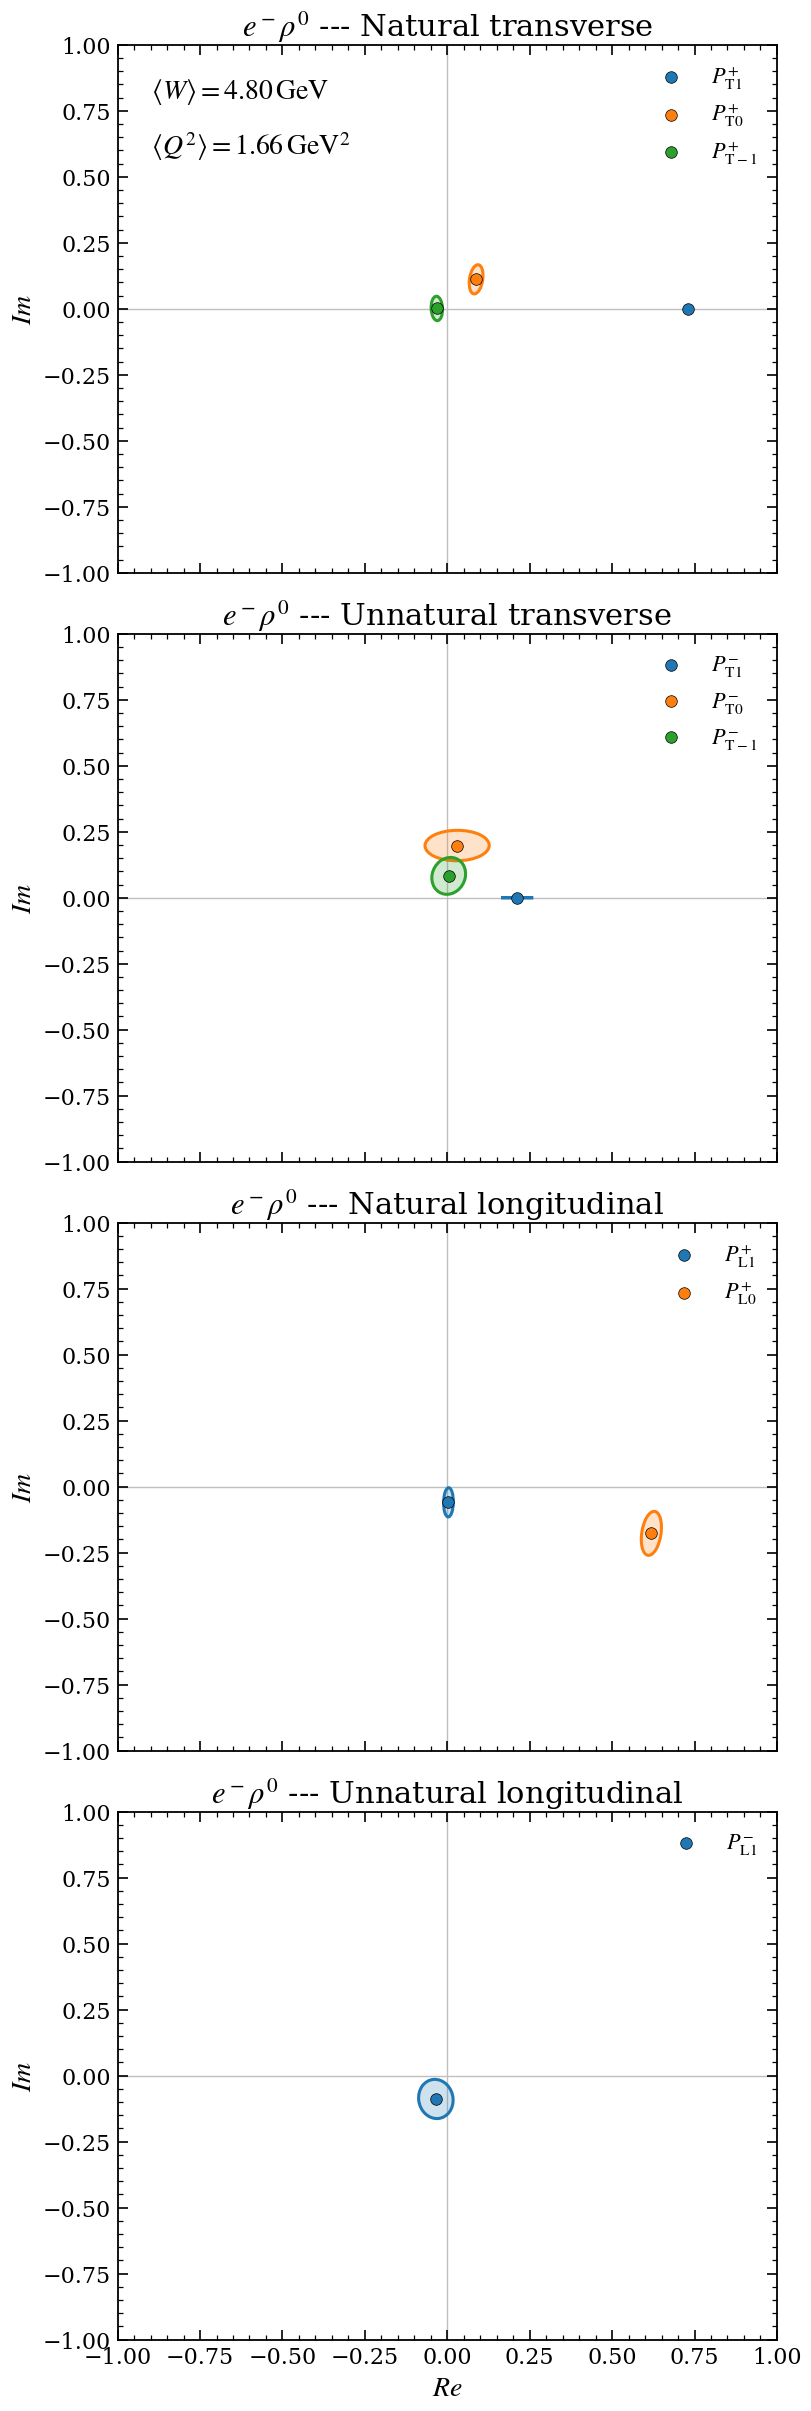

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_rho/ElRho_results_2_hessian_argand_poster.pdf


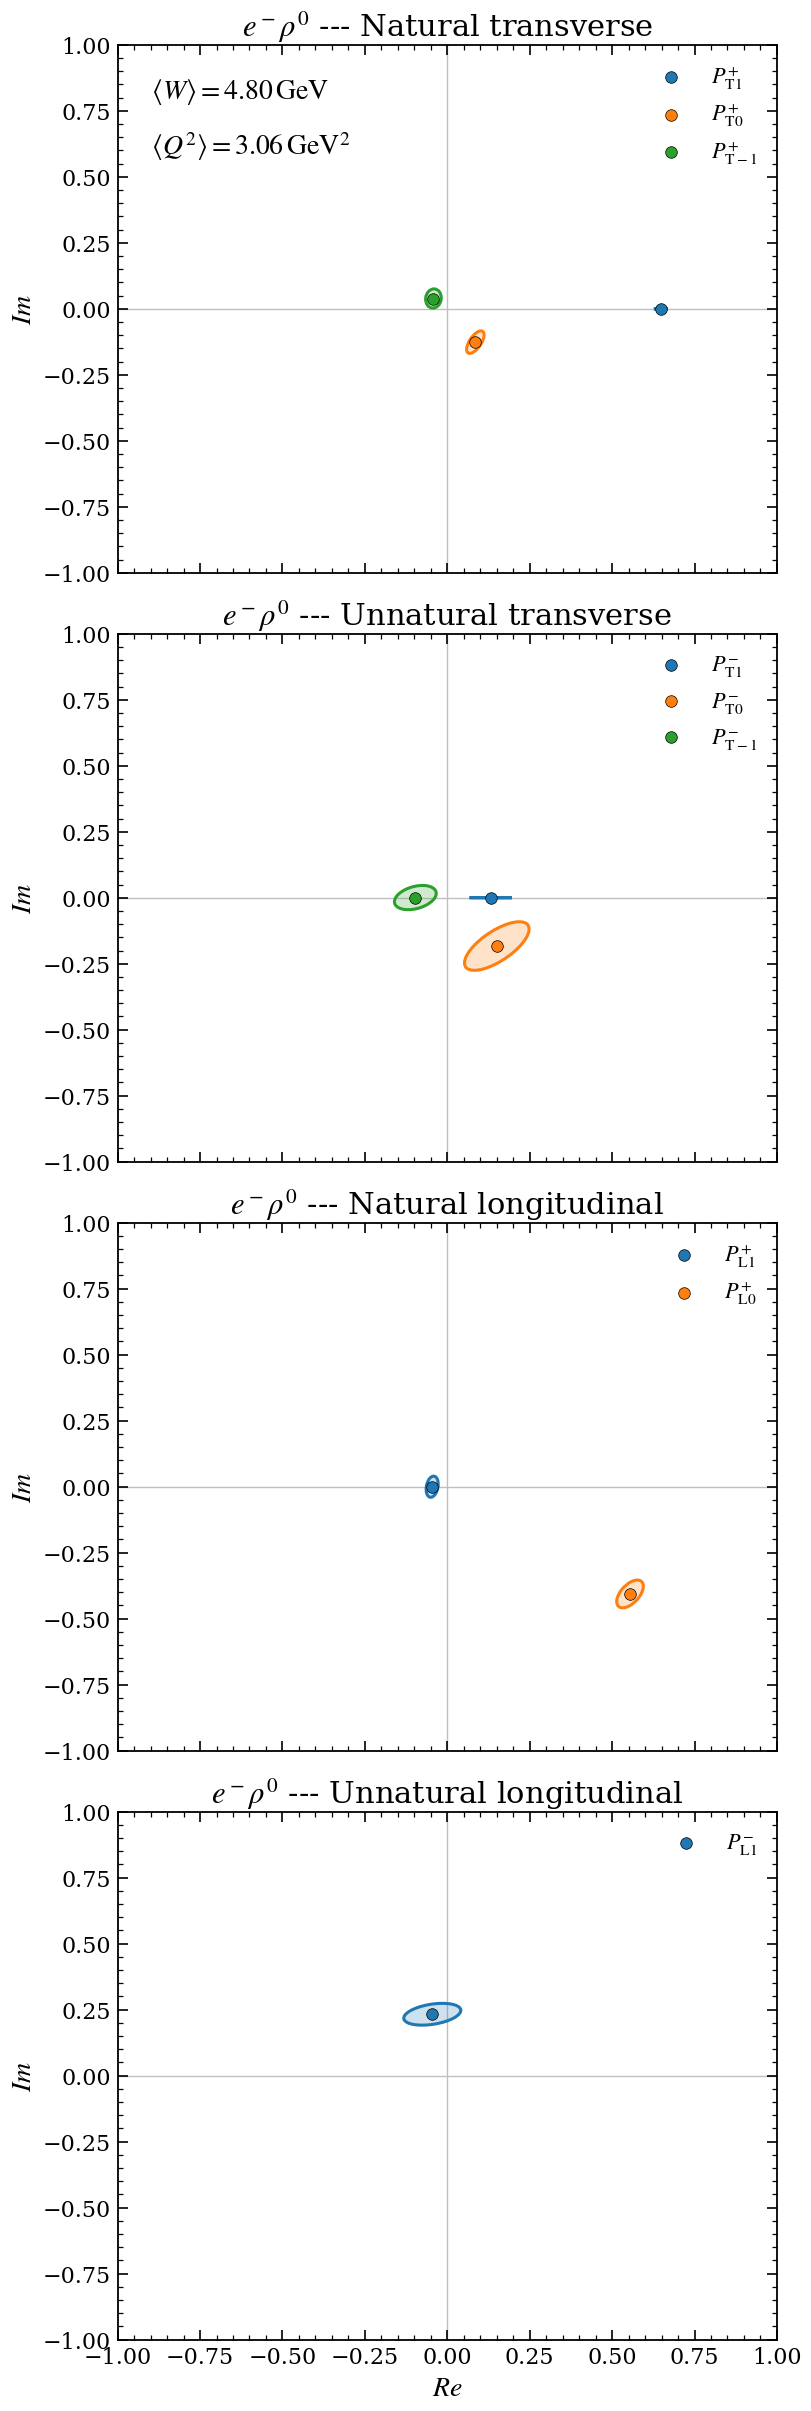

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_rho/ElRho_results_3_hessian_argand_poster.pdf


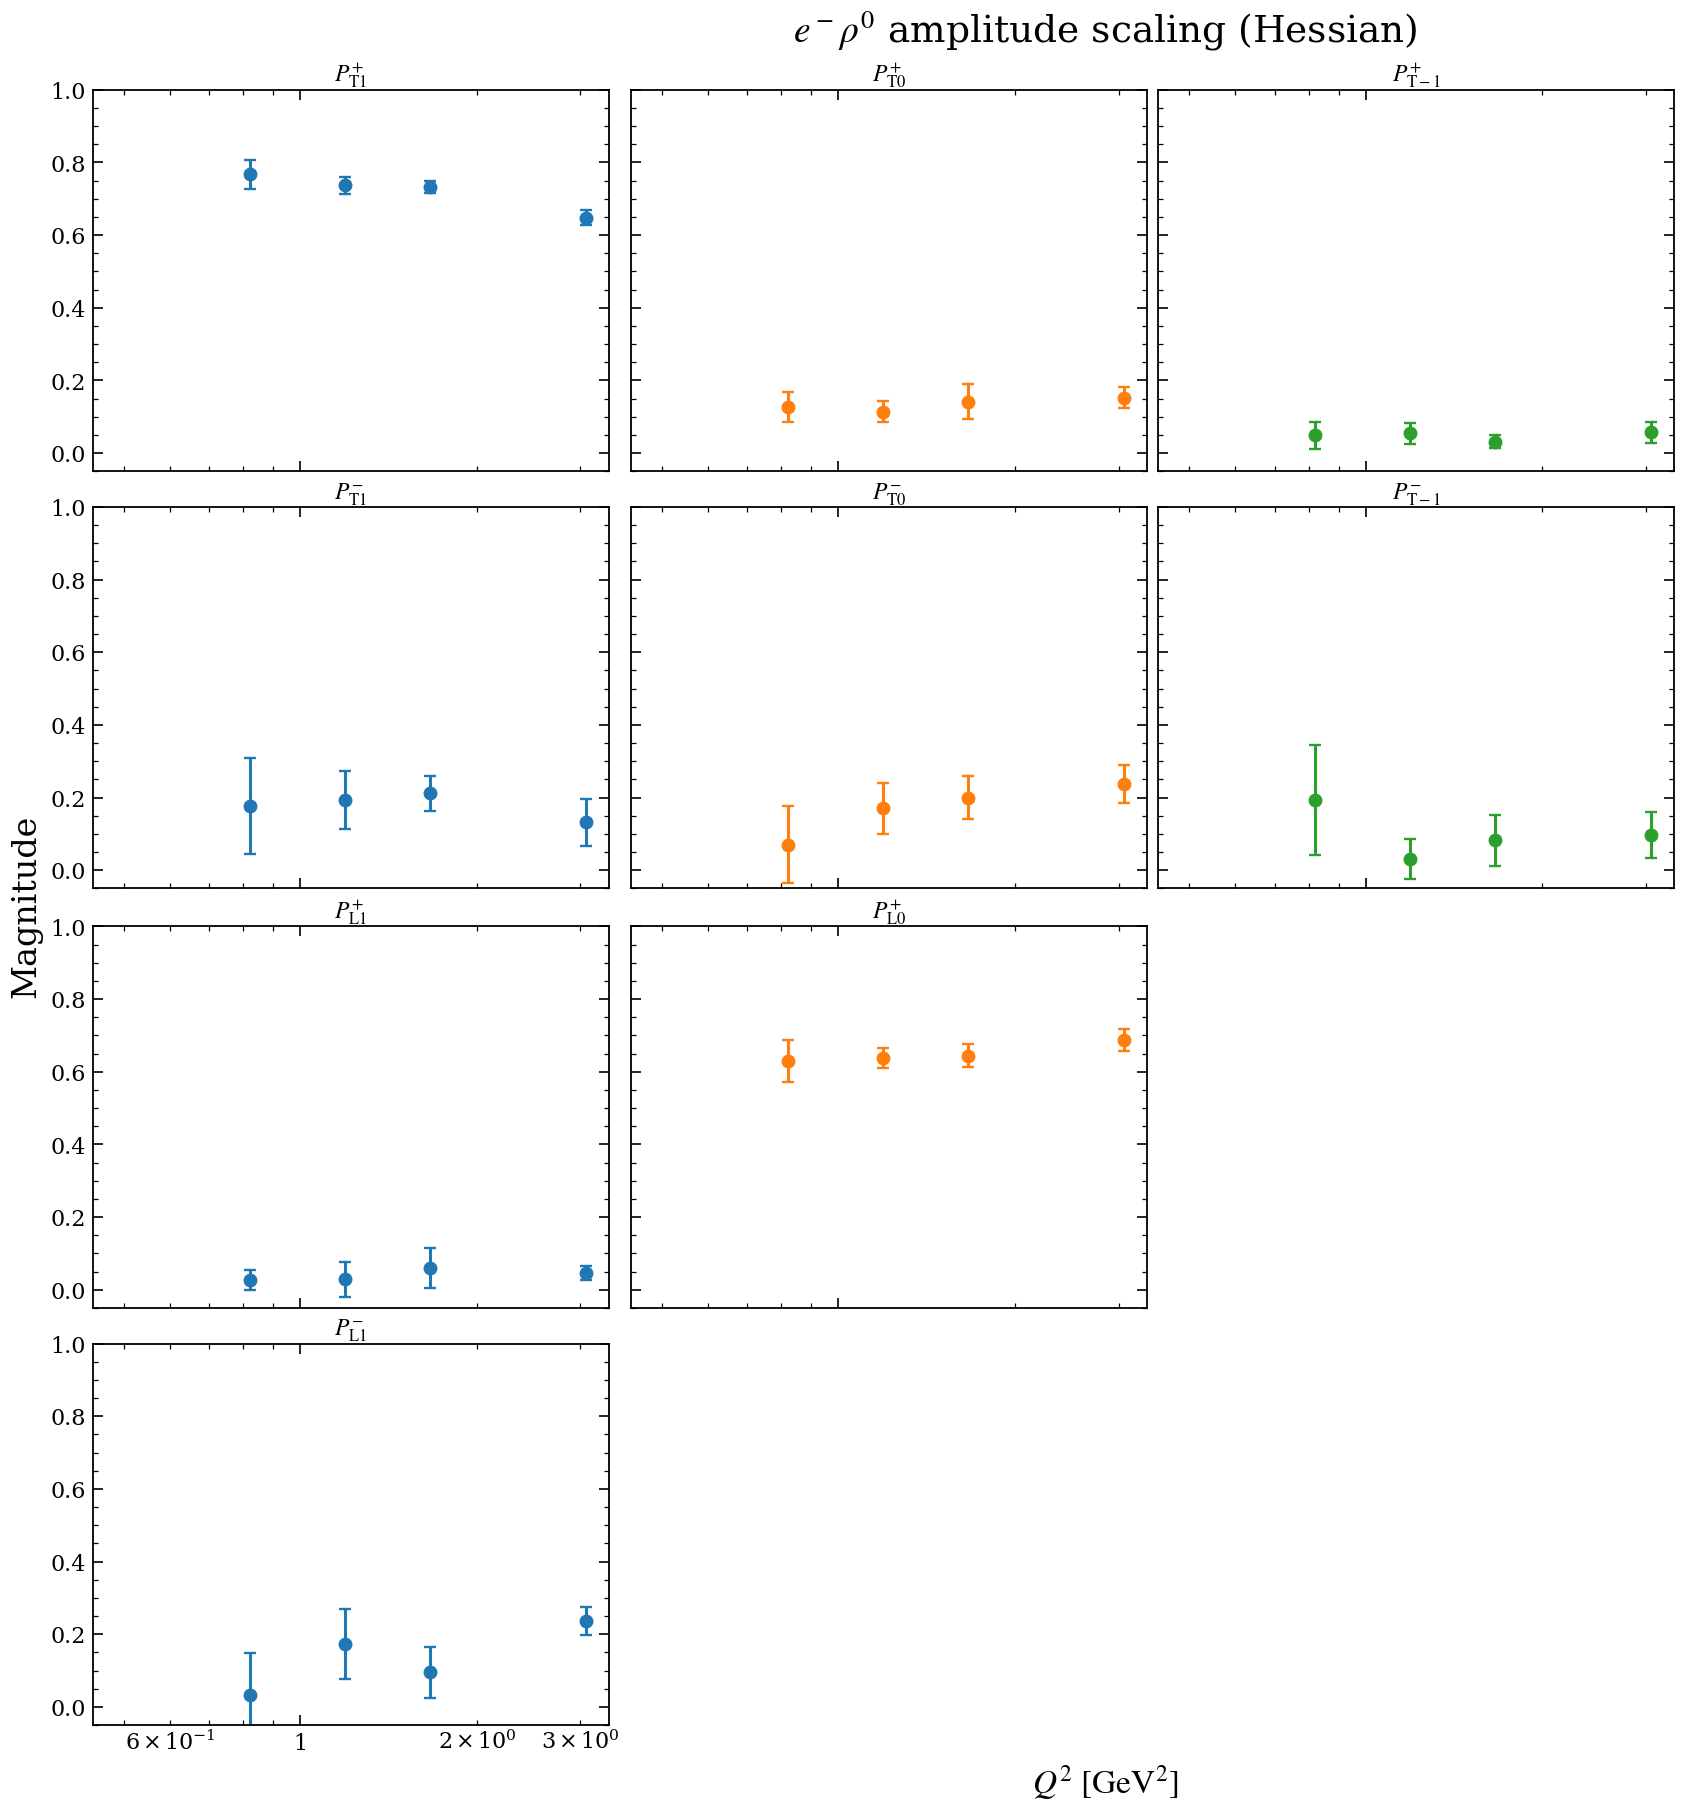

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_rho_hessian_scaling_poster.png


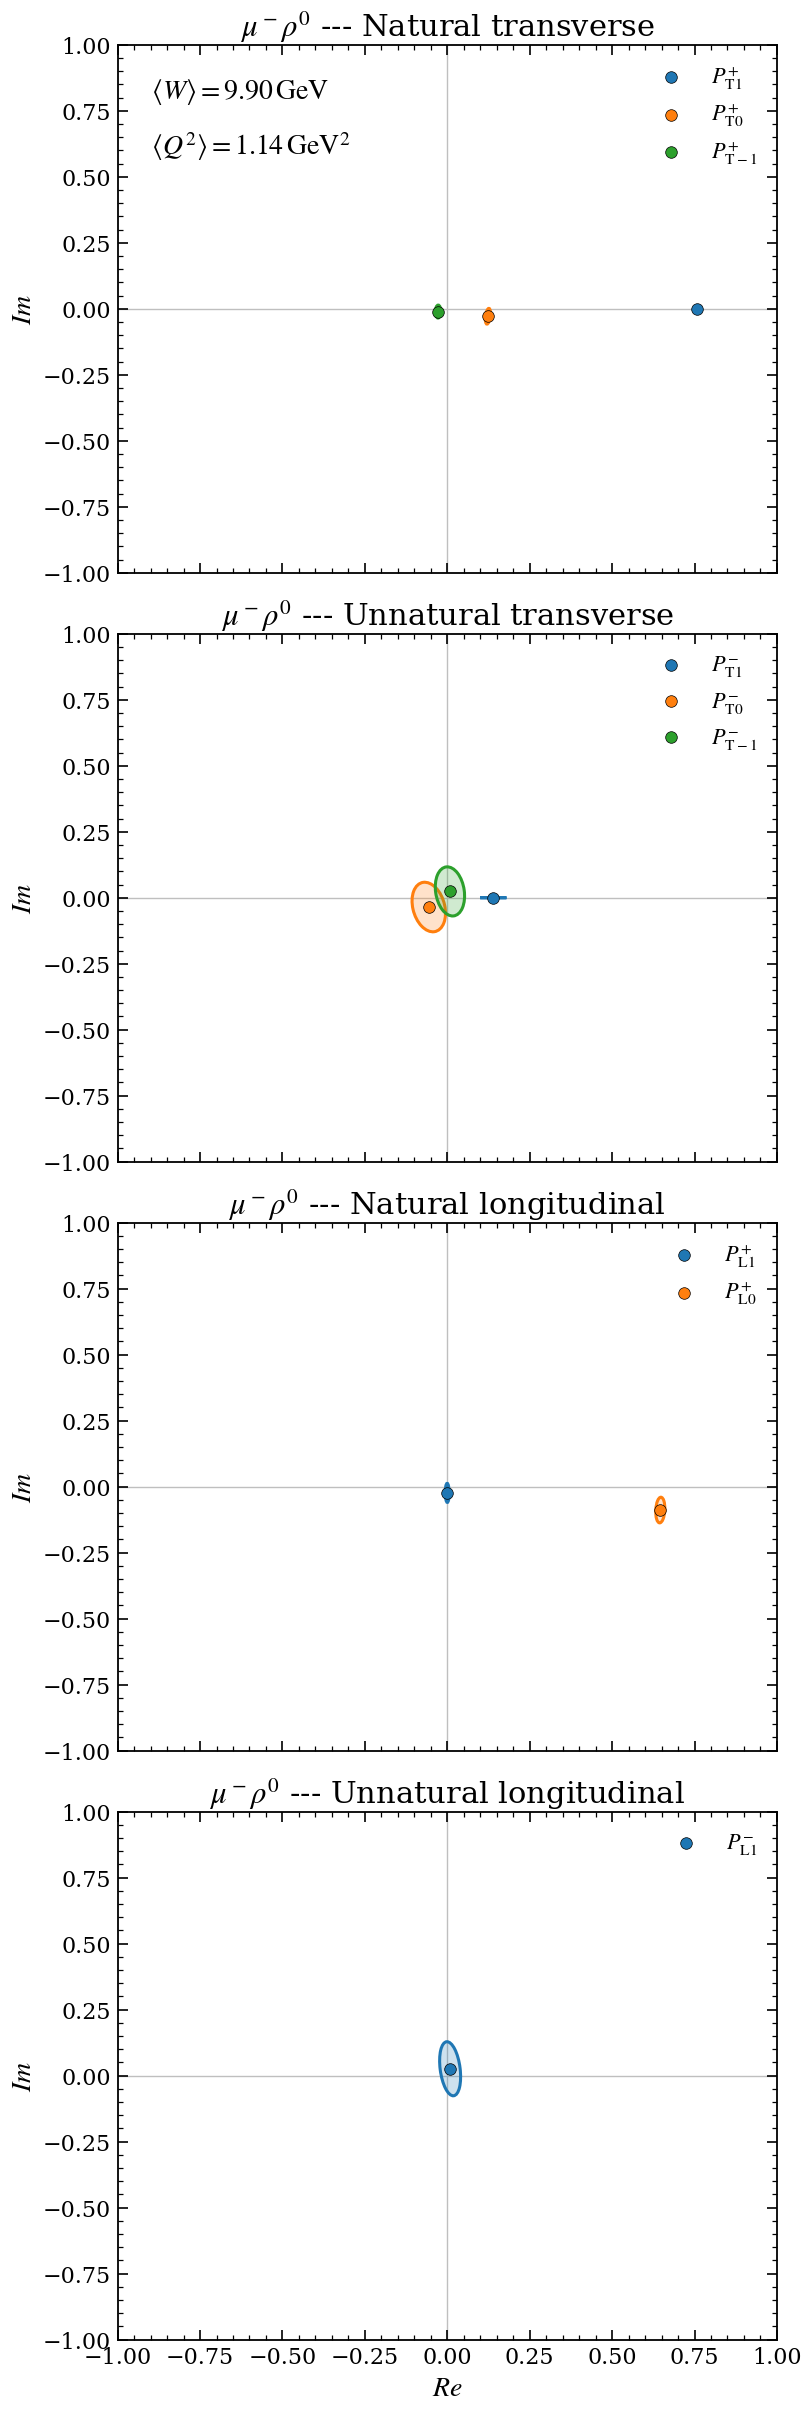

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/mu_rho/MuRho_results_0_hessian_argand_poster.pdf


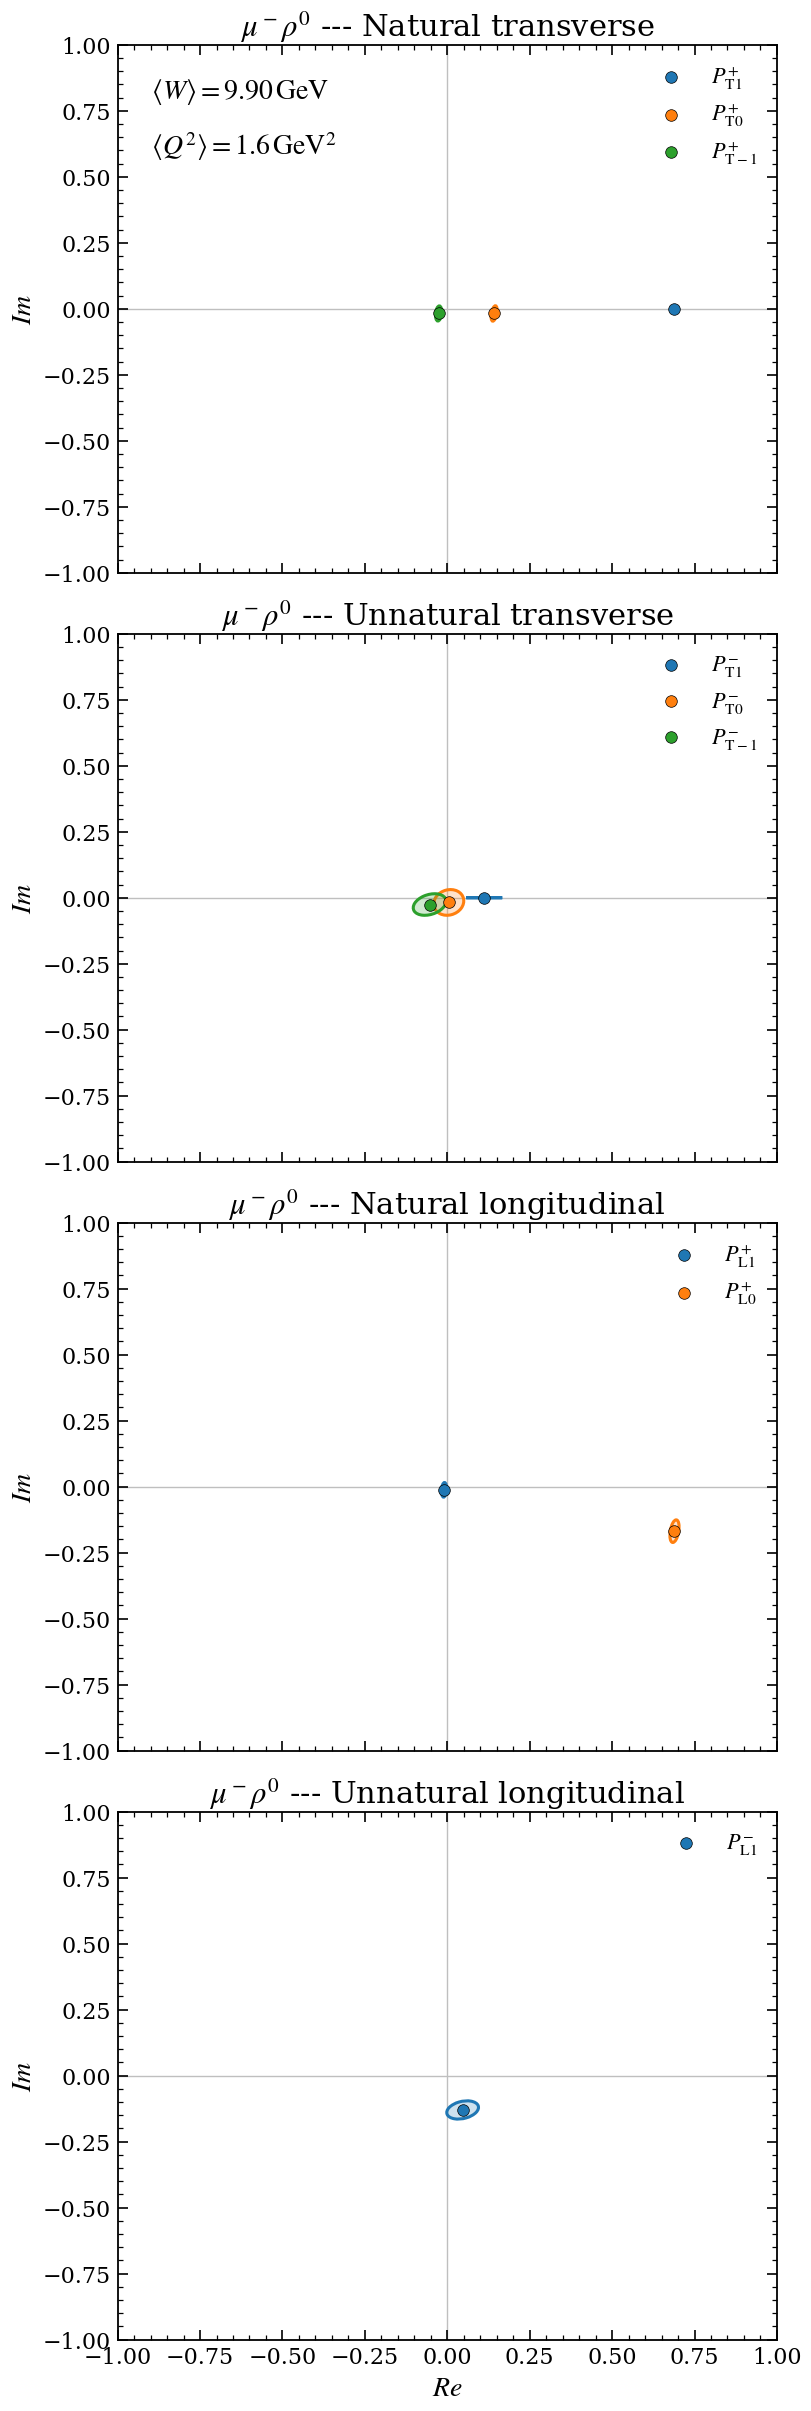

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/mu_rho/MuRho_results_1_hessian_argand_poster.pdf


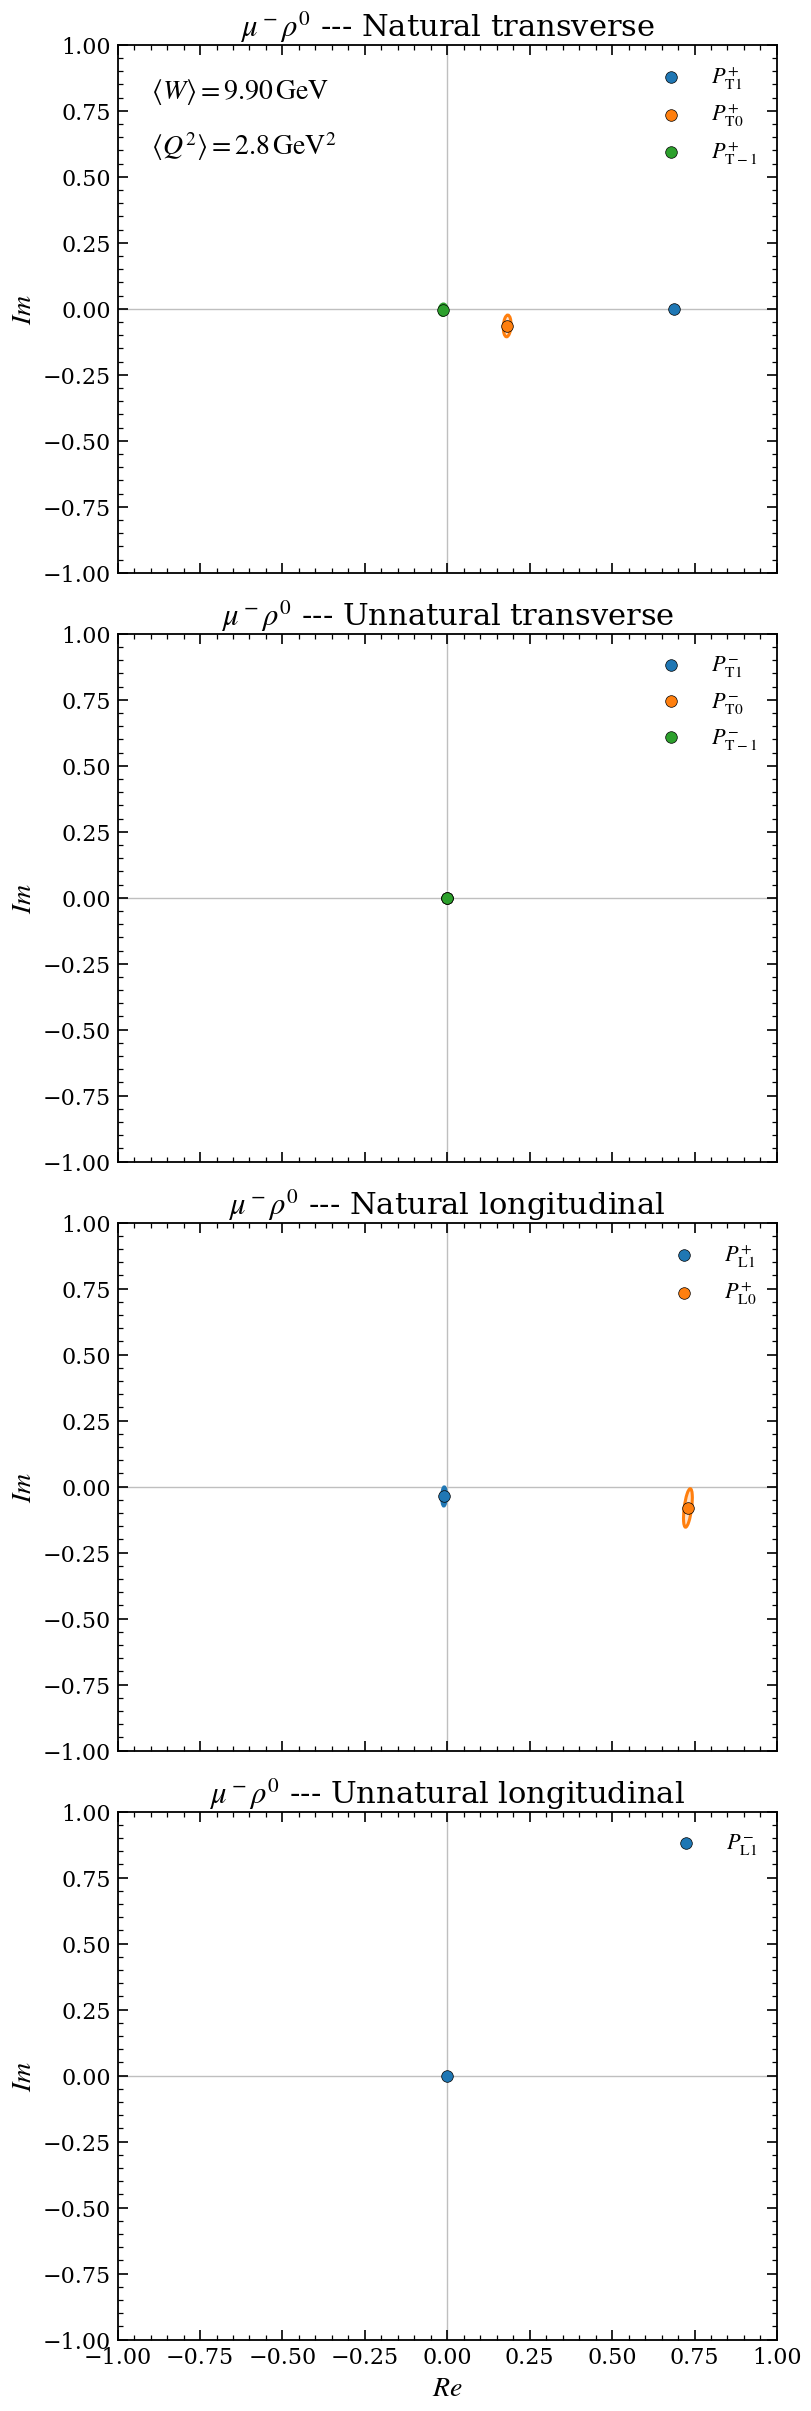

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/mu_rho/MuRho_results_2_hessian_argand_poster.pdf


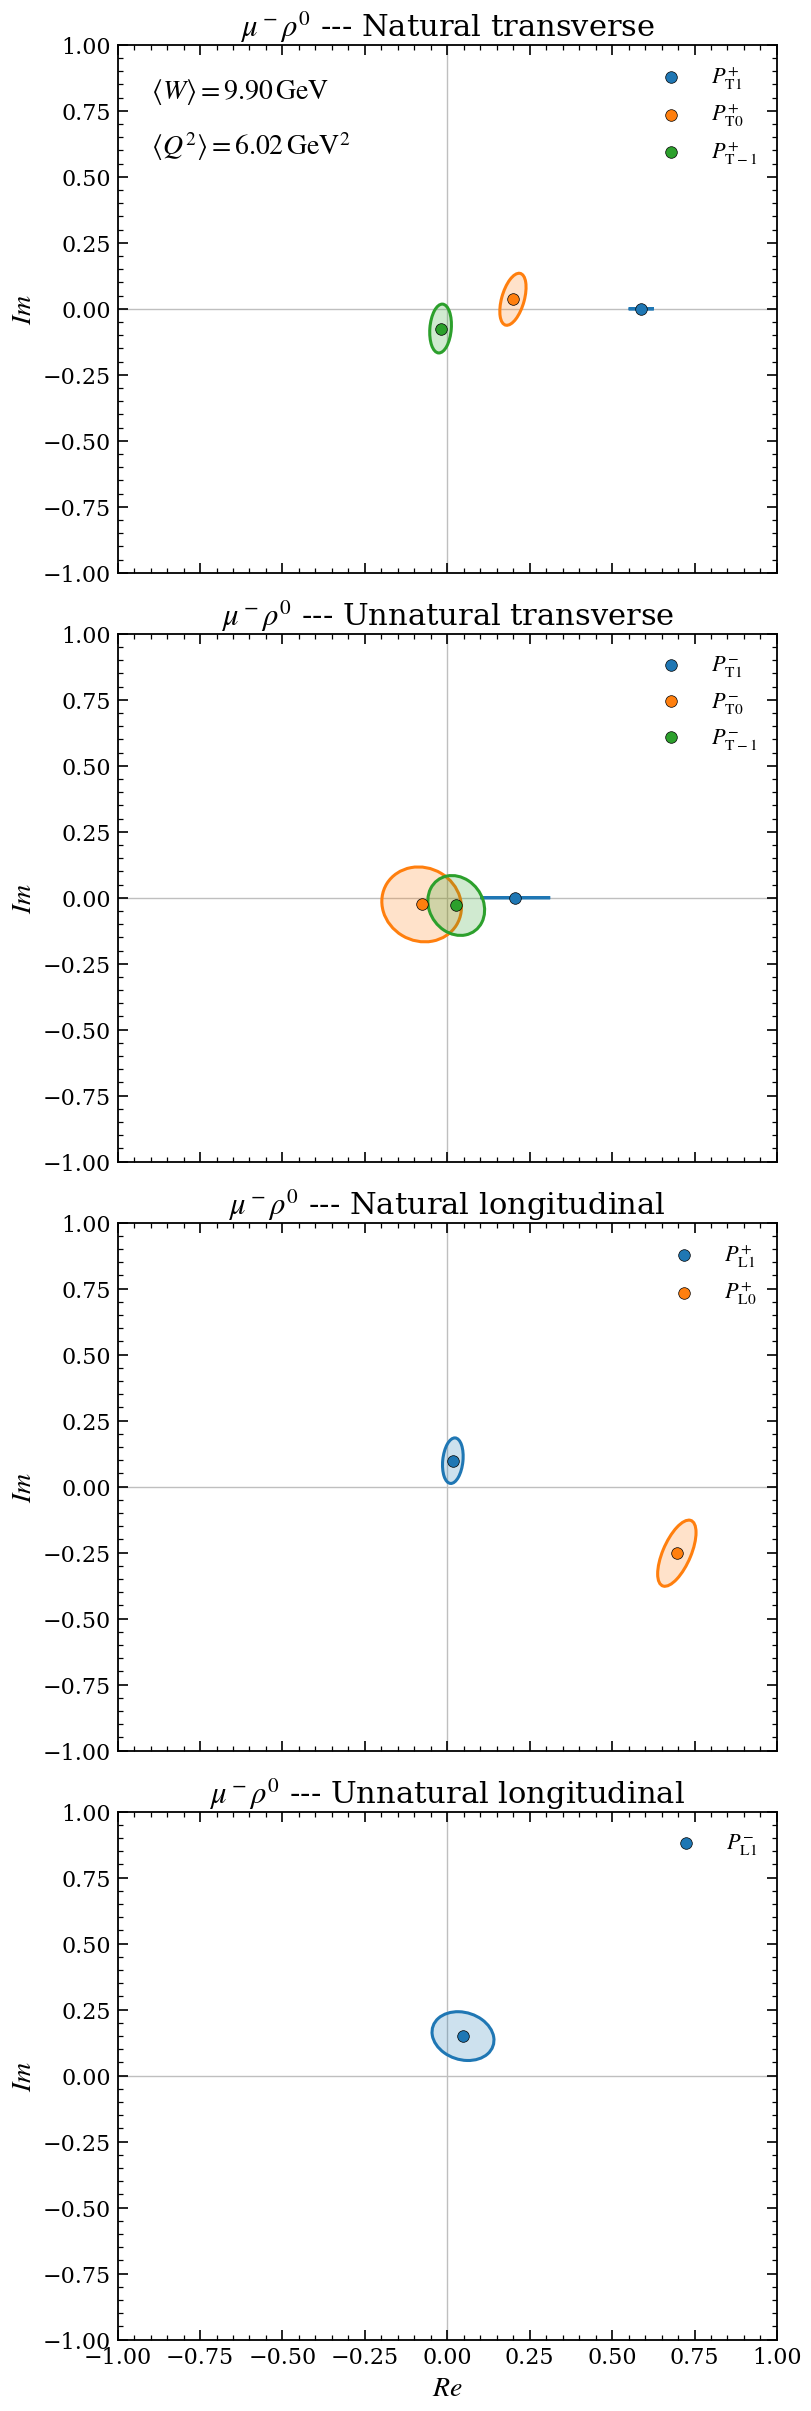

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/mu_rho/MuRho_results_3_hessian_argand_poster.pdf


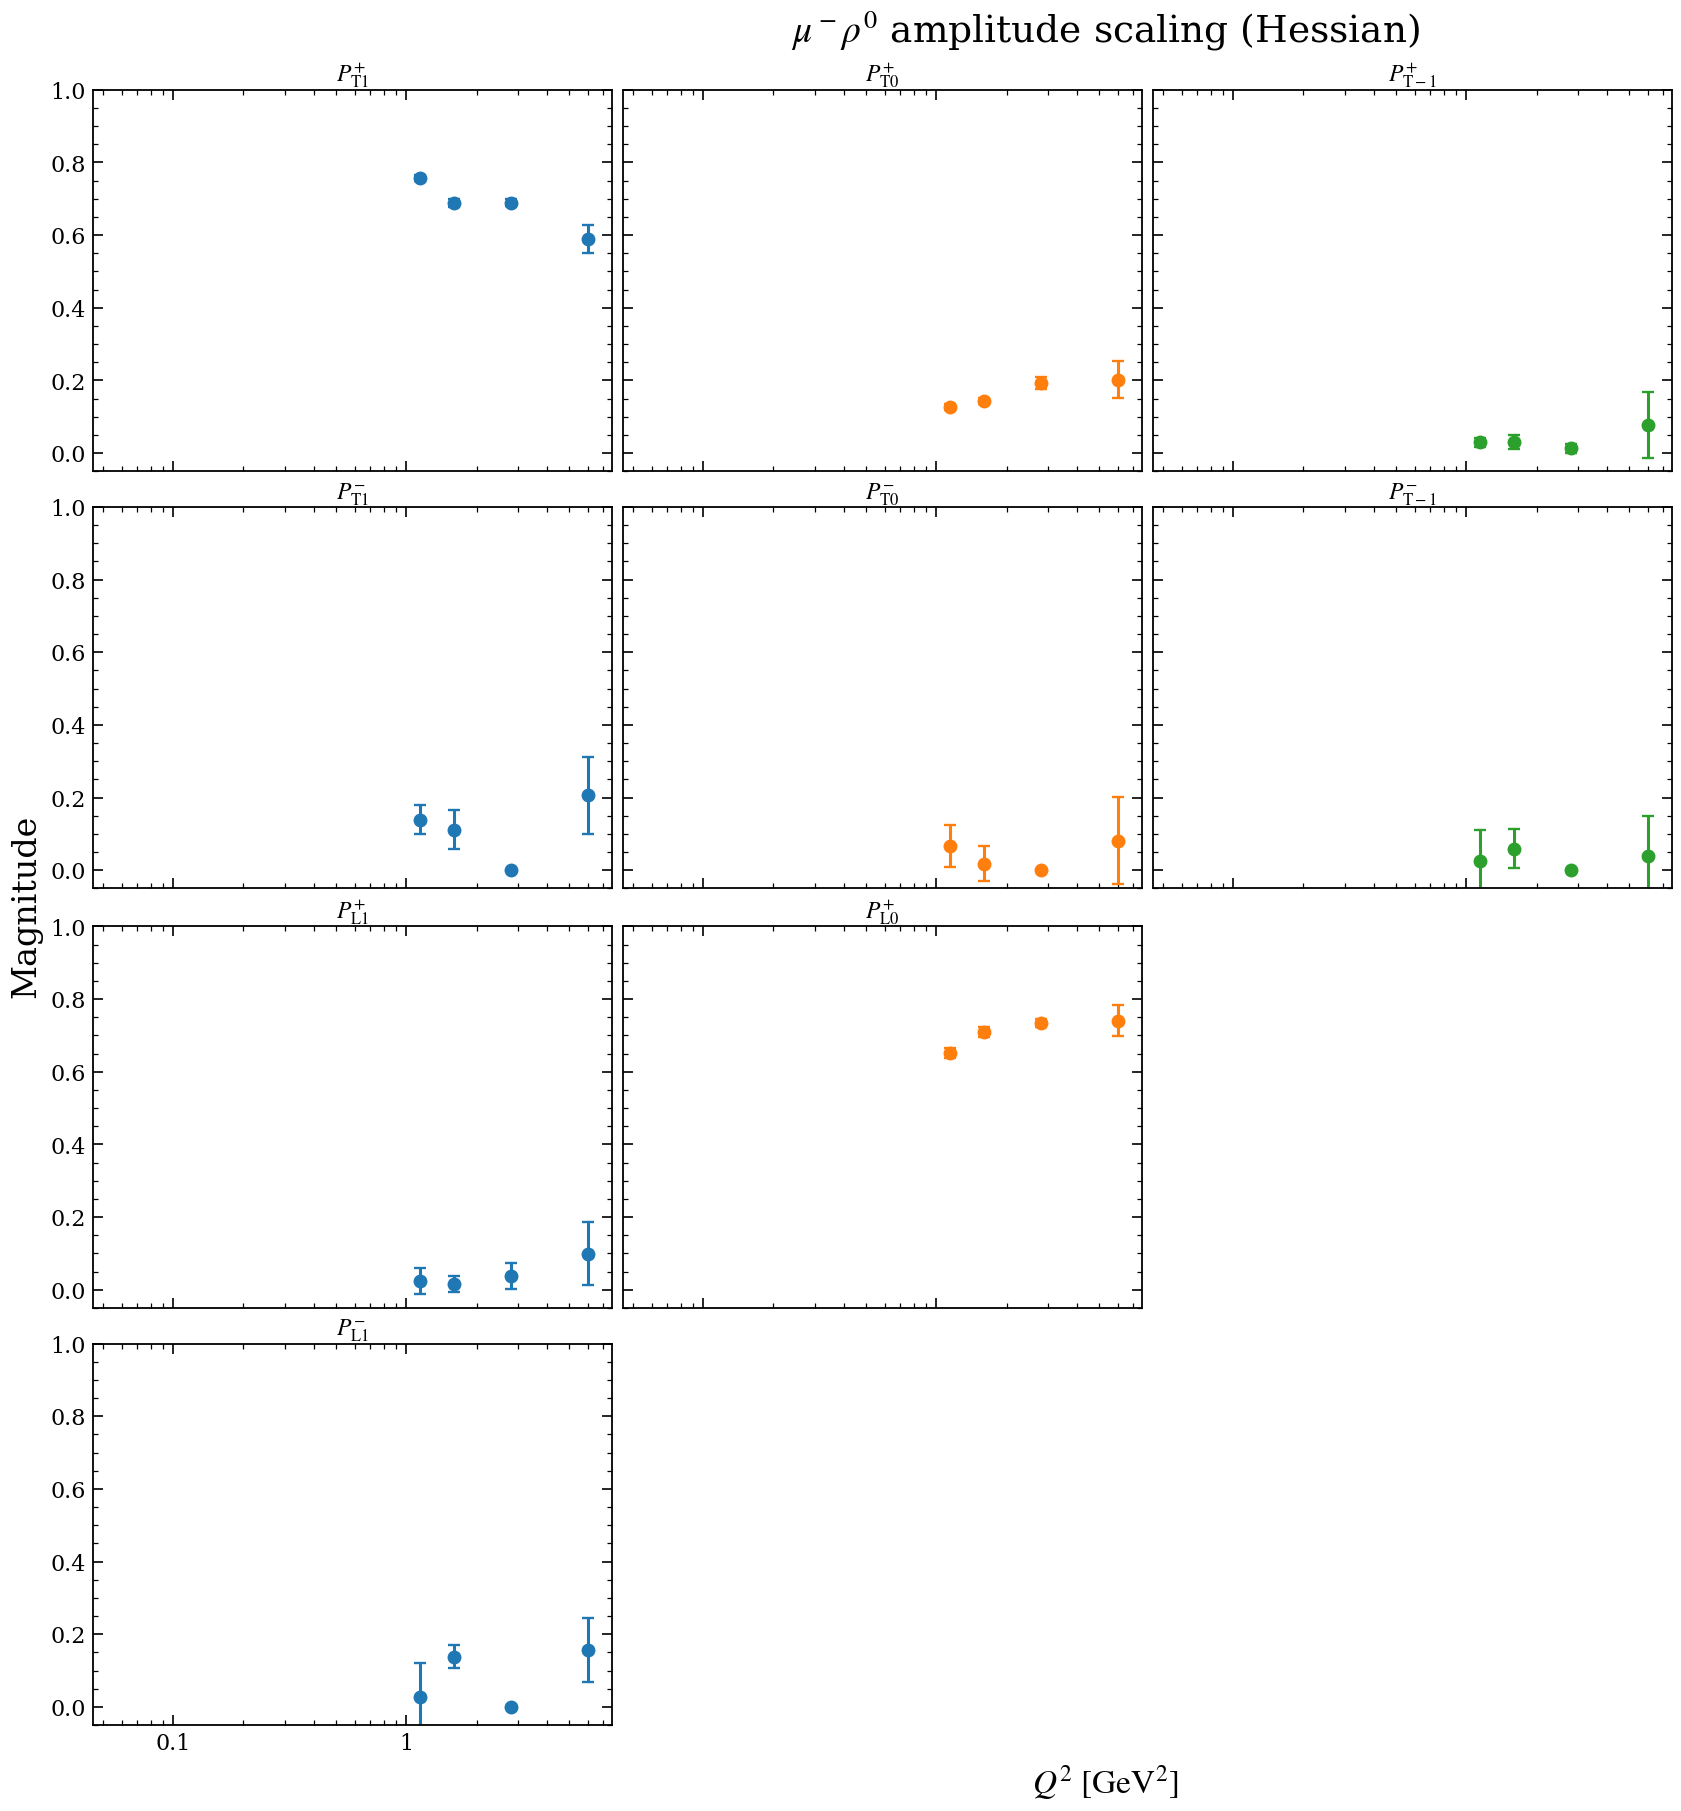

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/mu_rho_hessian_scaling_poster.png


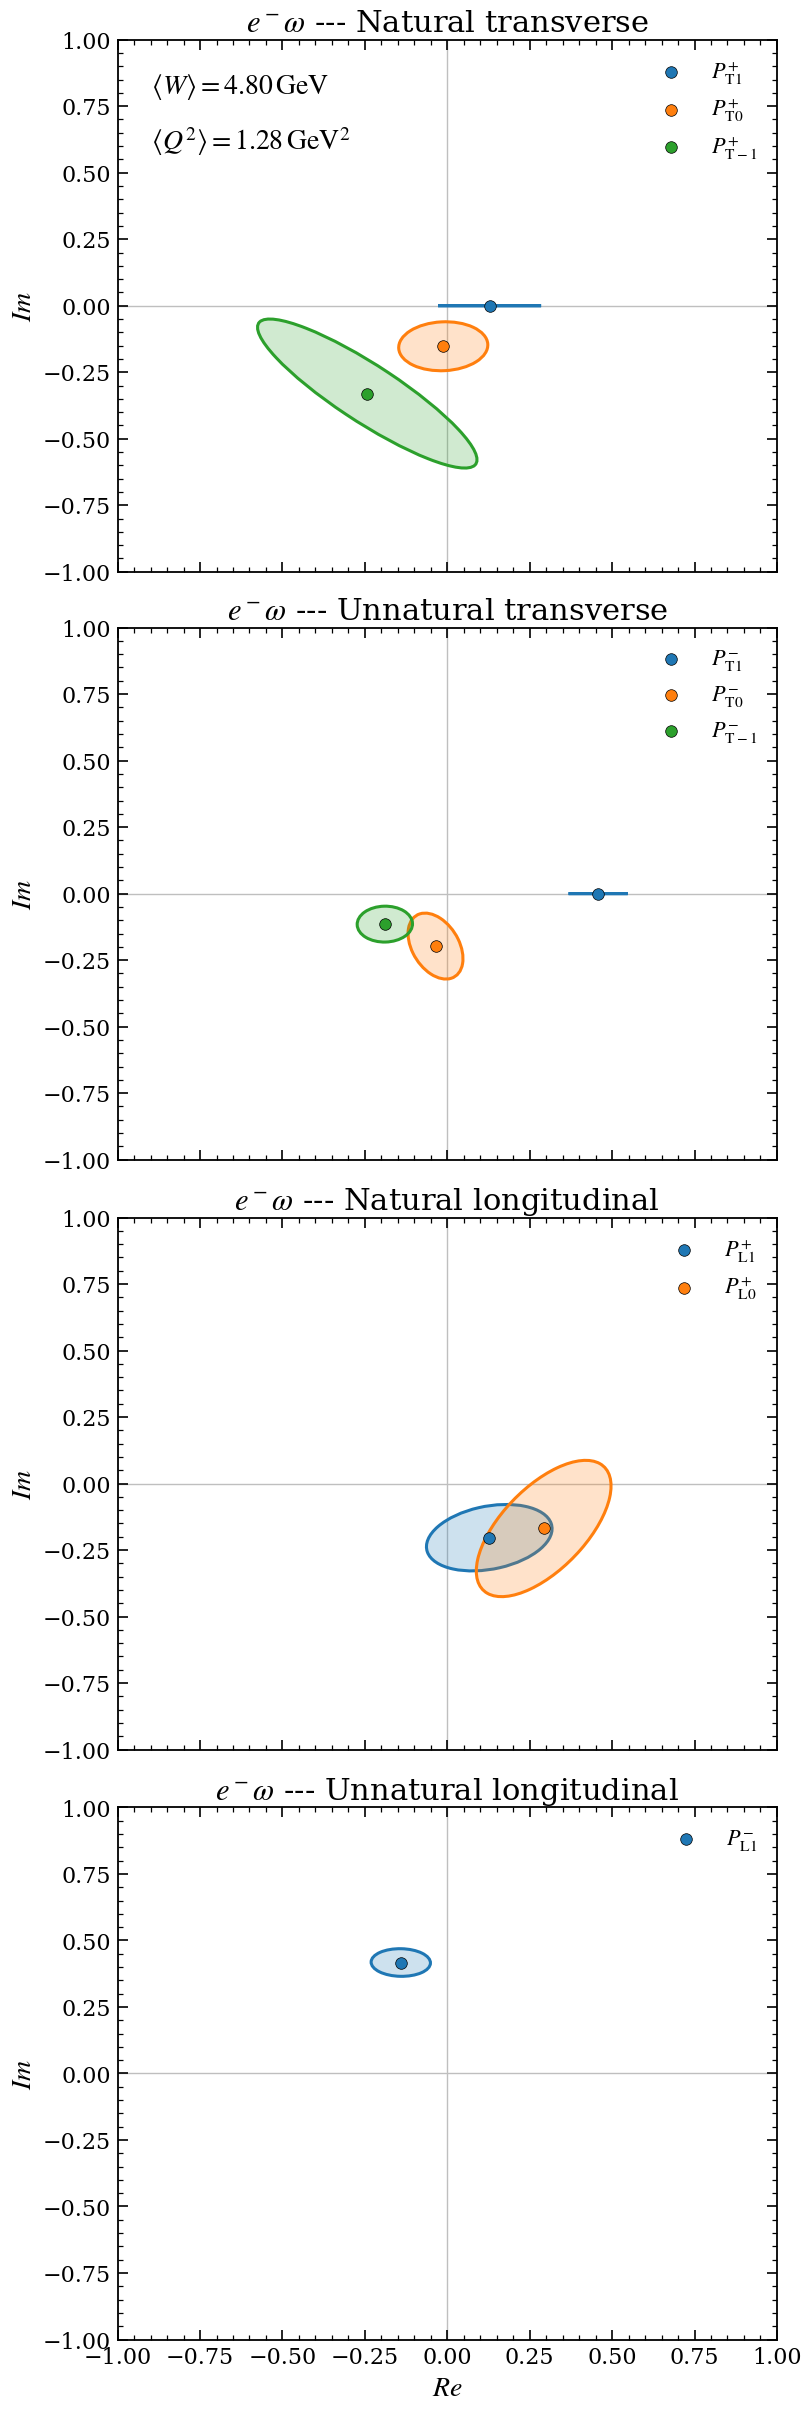

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_omega/ElOmega_results_0_hessian_argand_poster.pdf


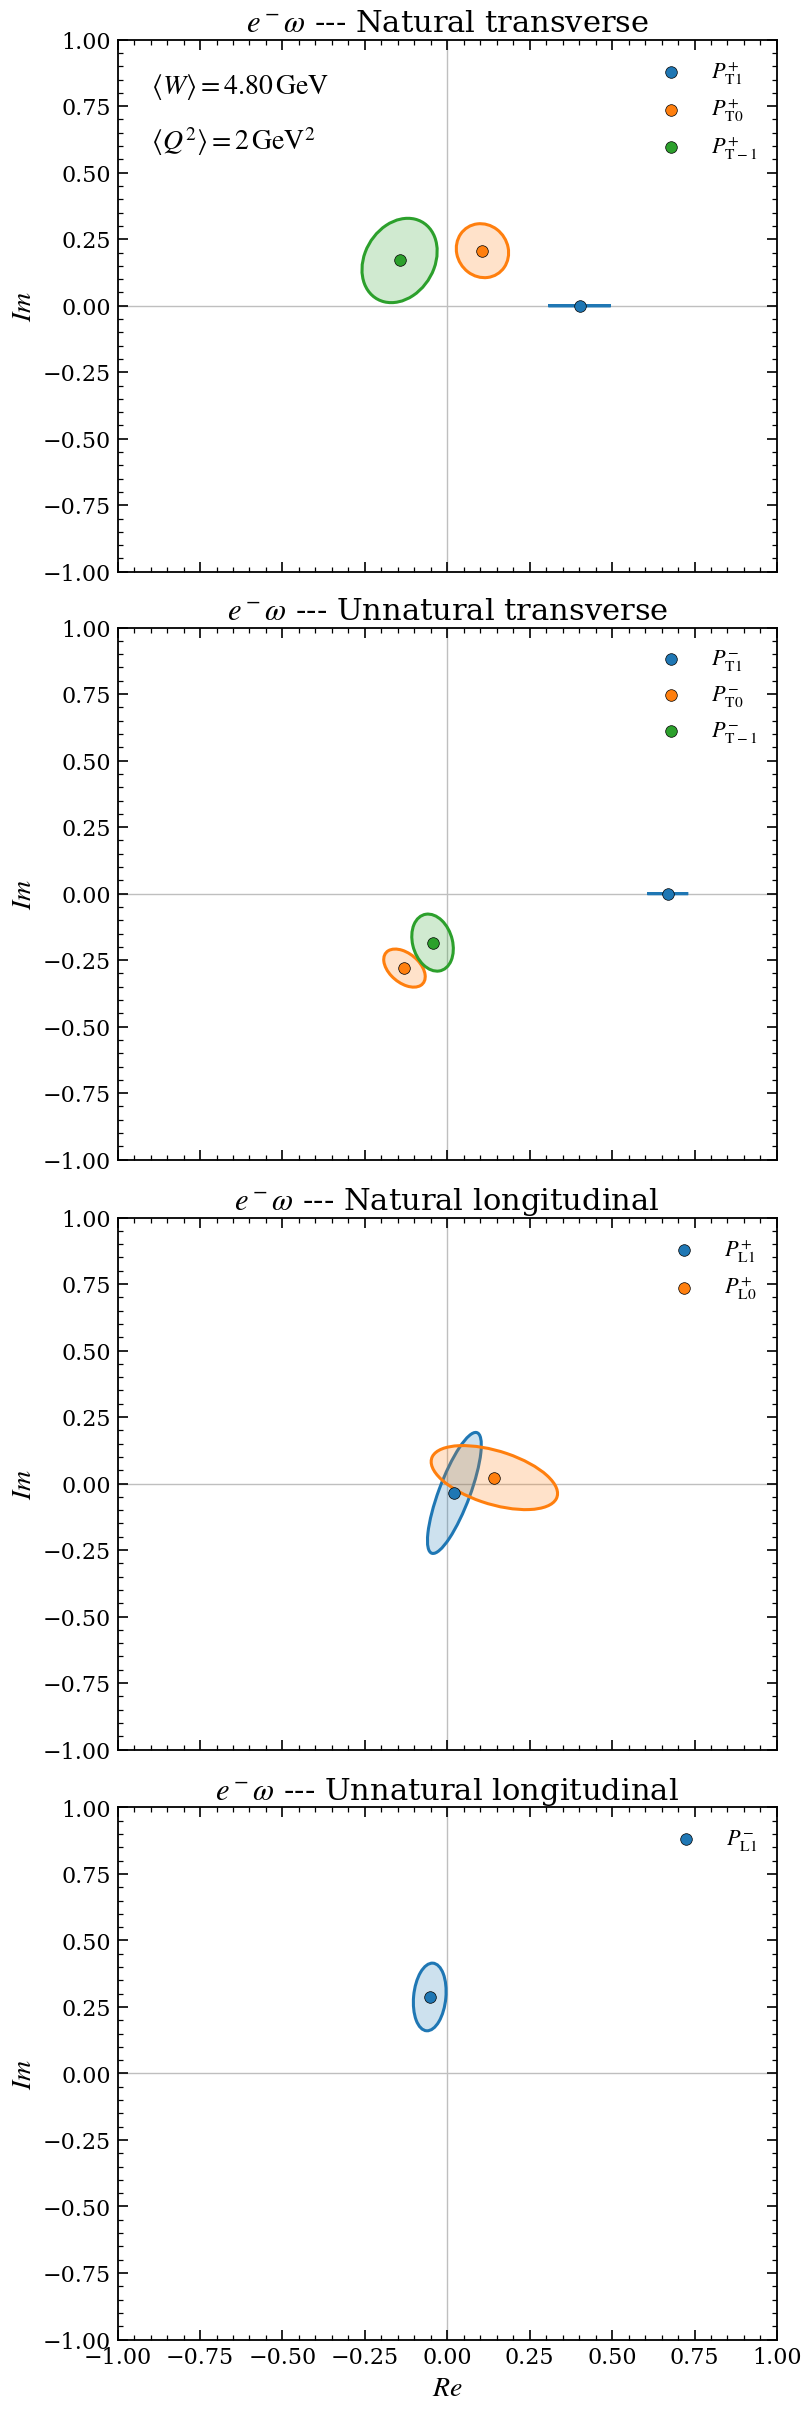

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_omega/ElOmega_results_1_hessian_argand_poster.pdf


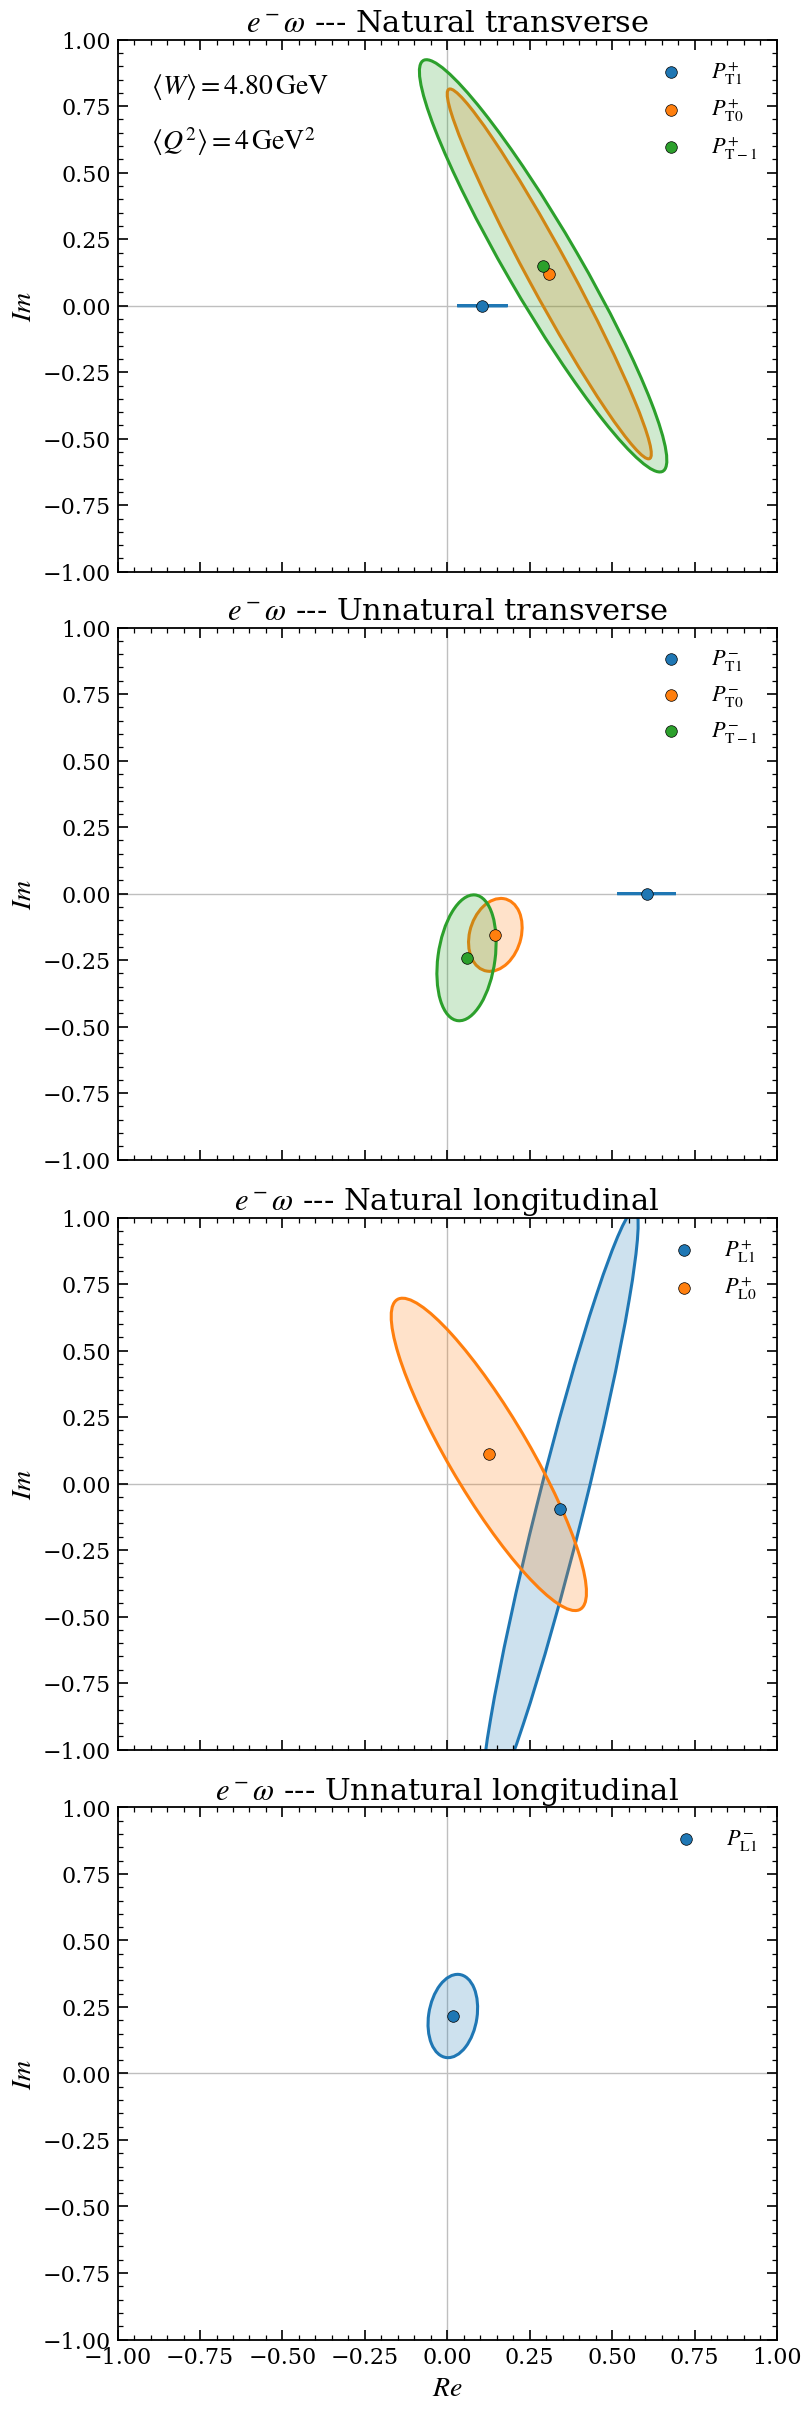

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_omega/ElOmega_results_2_hessian_argand_poster.pdf


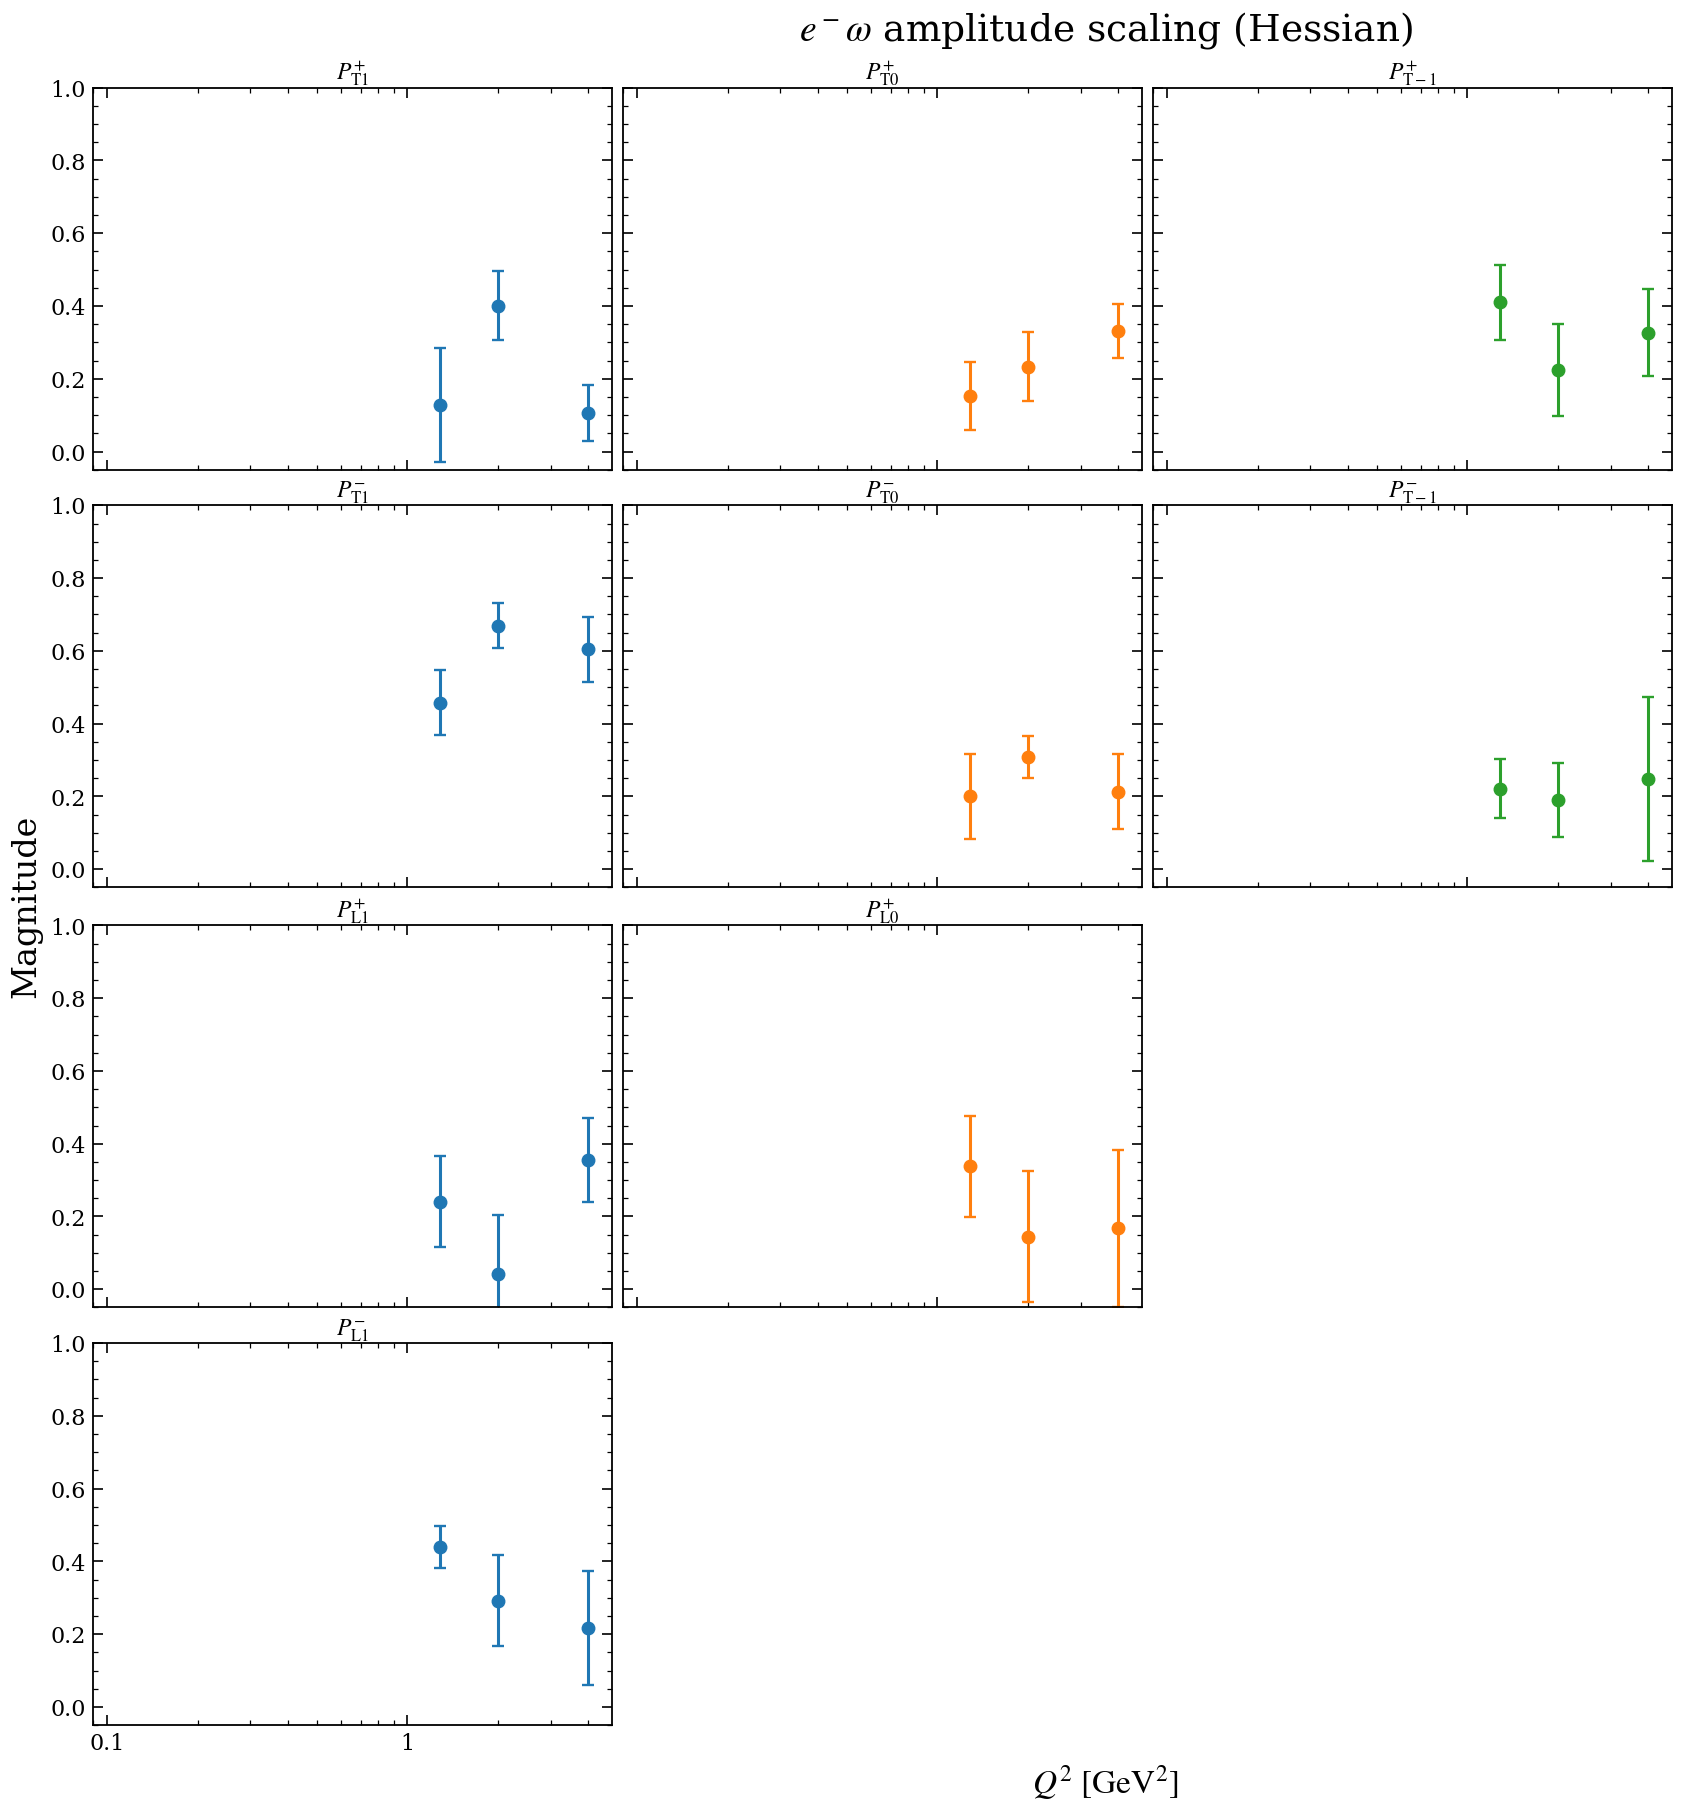

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_omega_hessian_scaling_poster.png


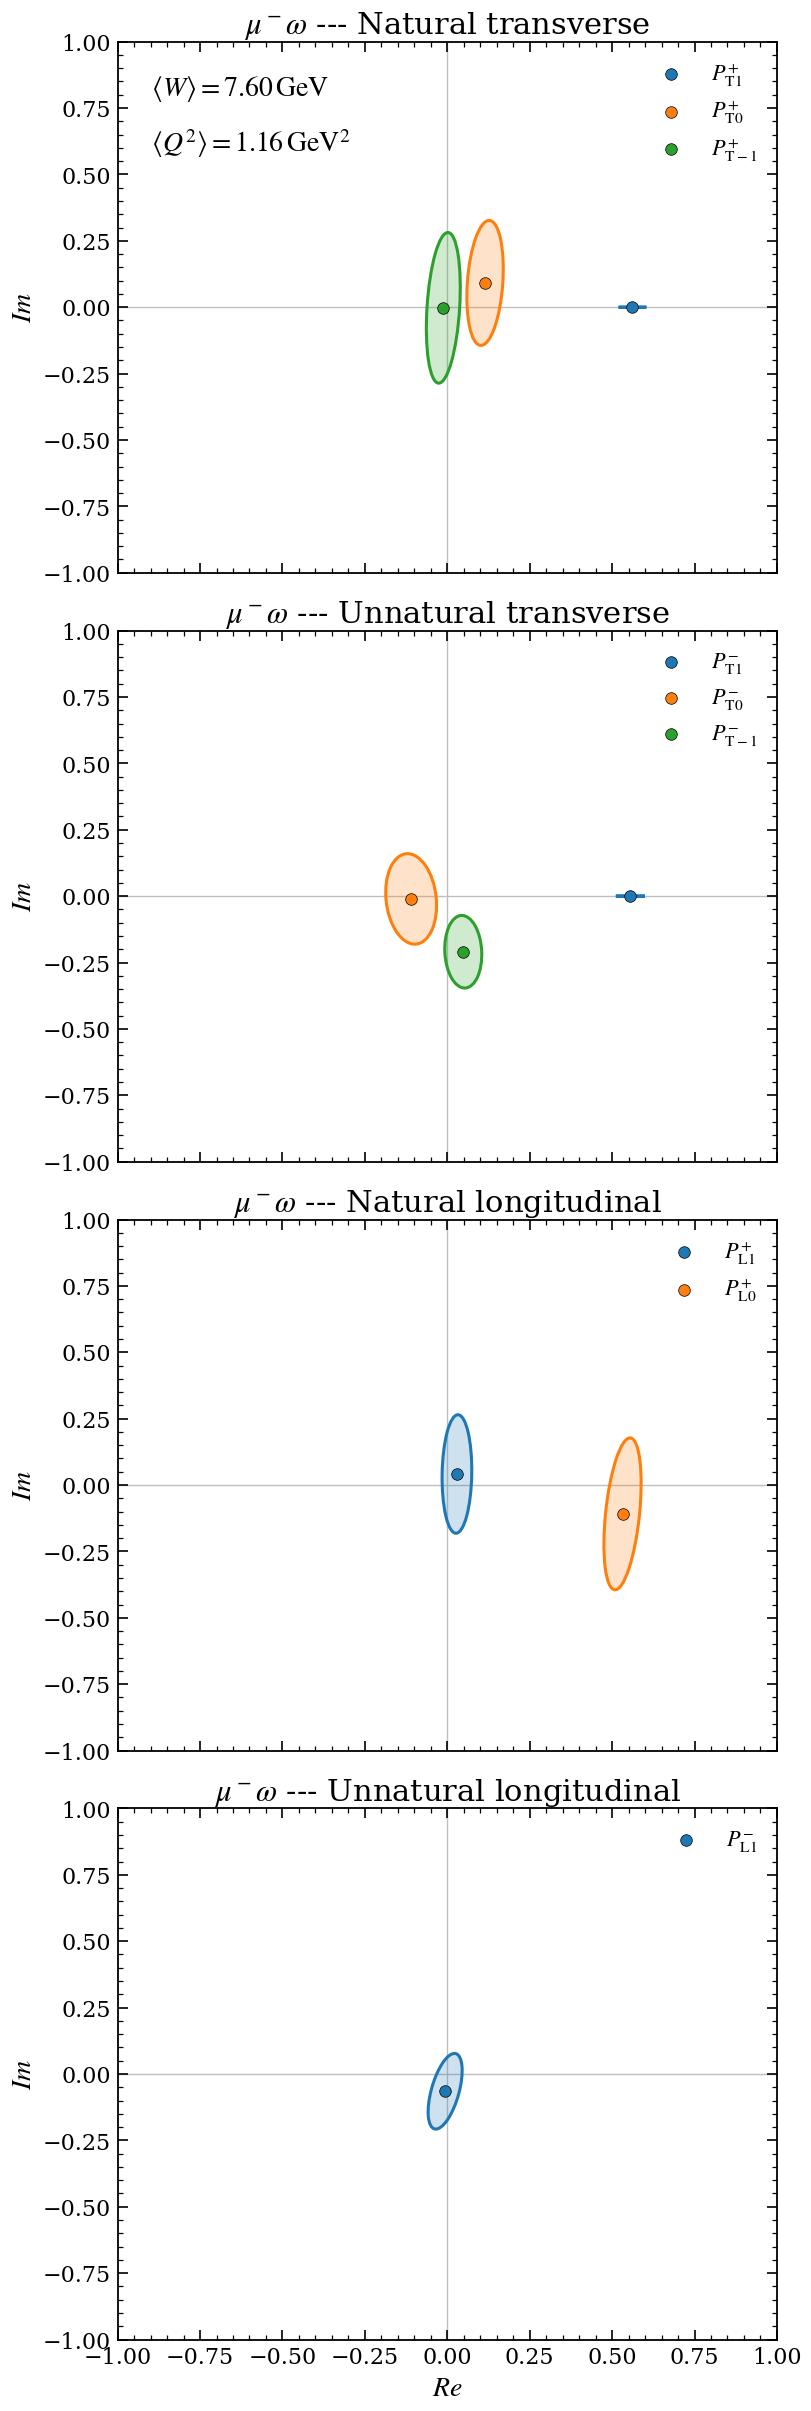

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/mu_omega/MuOmega_results_0_hessian_argand_poster.pdf


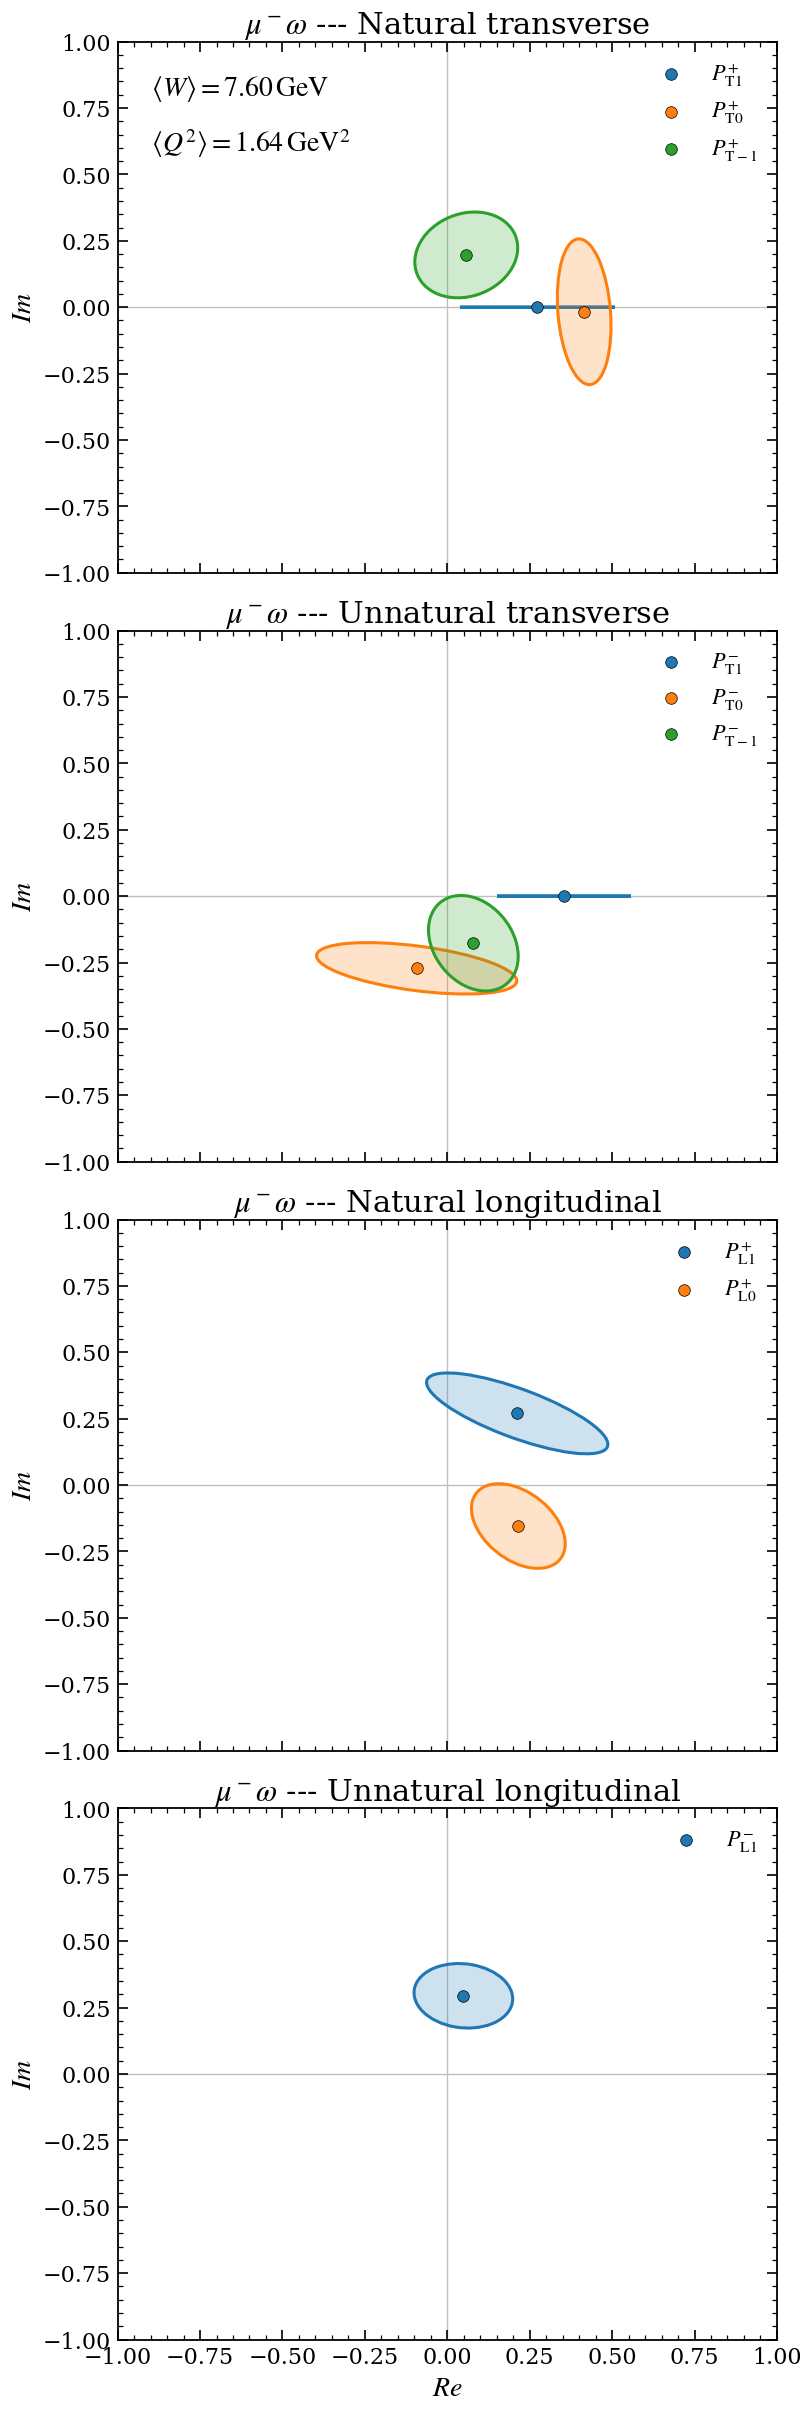

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/mu_omega/MuOmega_results_1_hessian_argand_poster.pdf


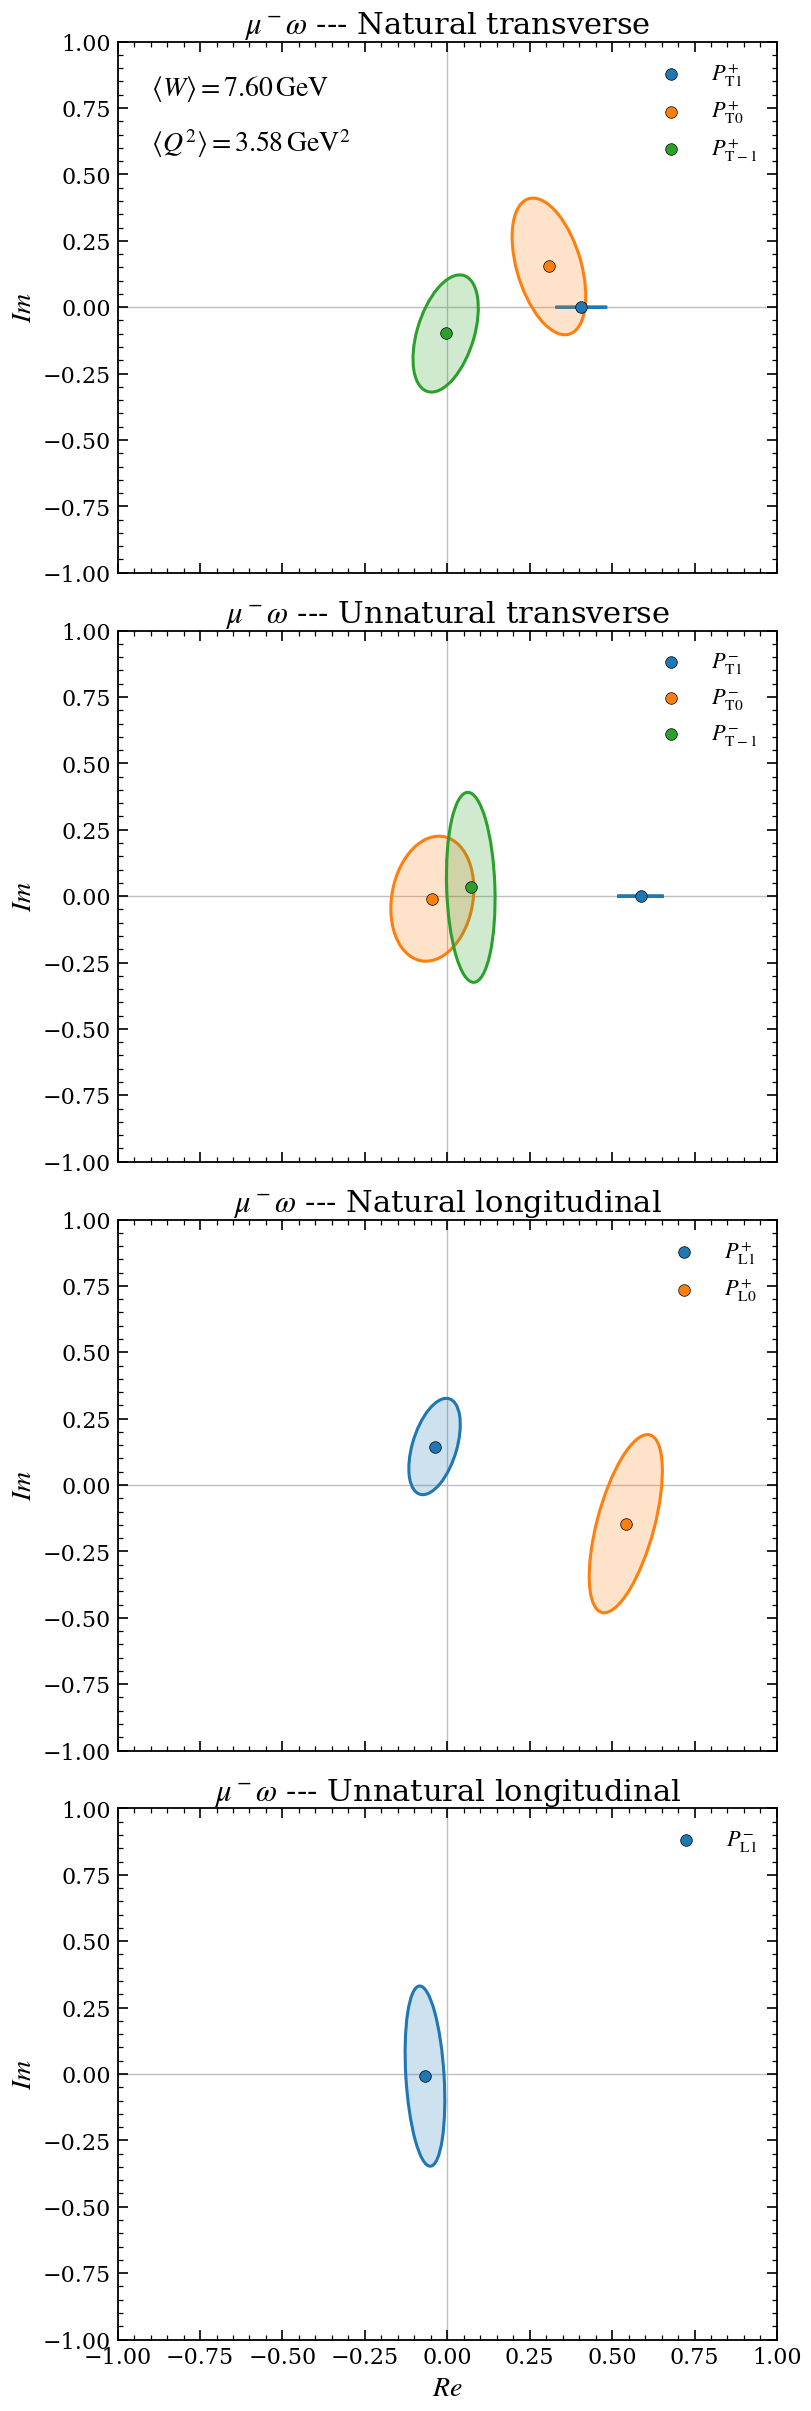

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/mu_omega/MuOmega_results_2_hessian_argand_poster.pdf


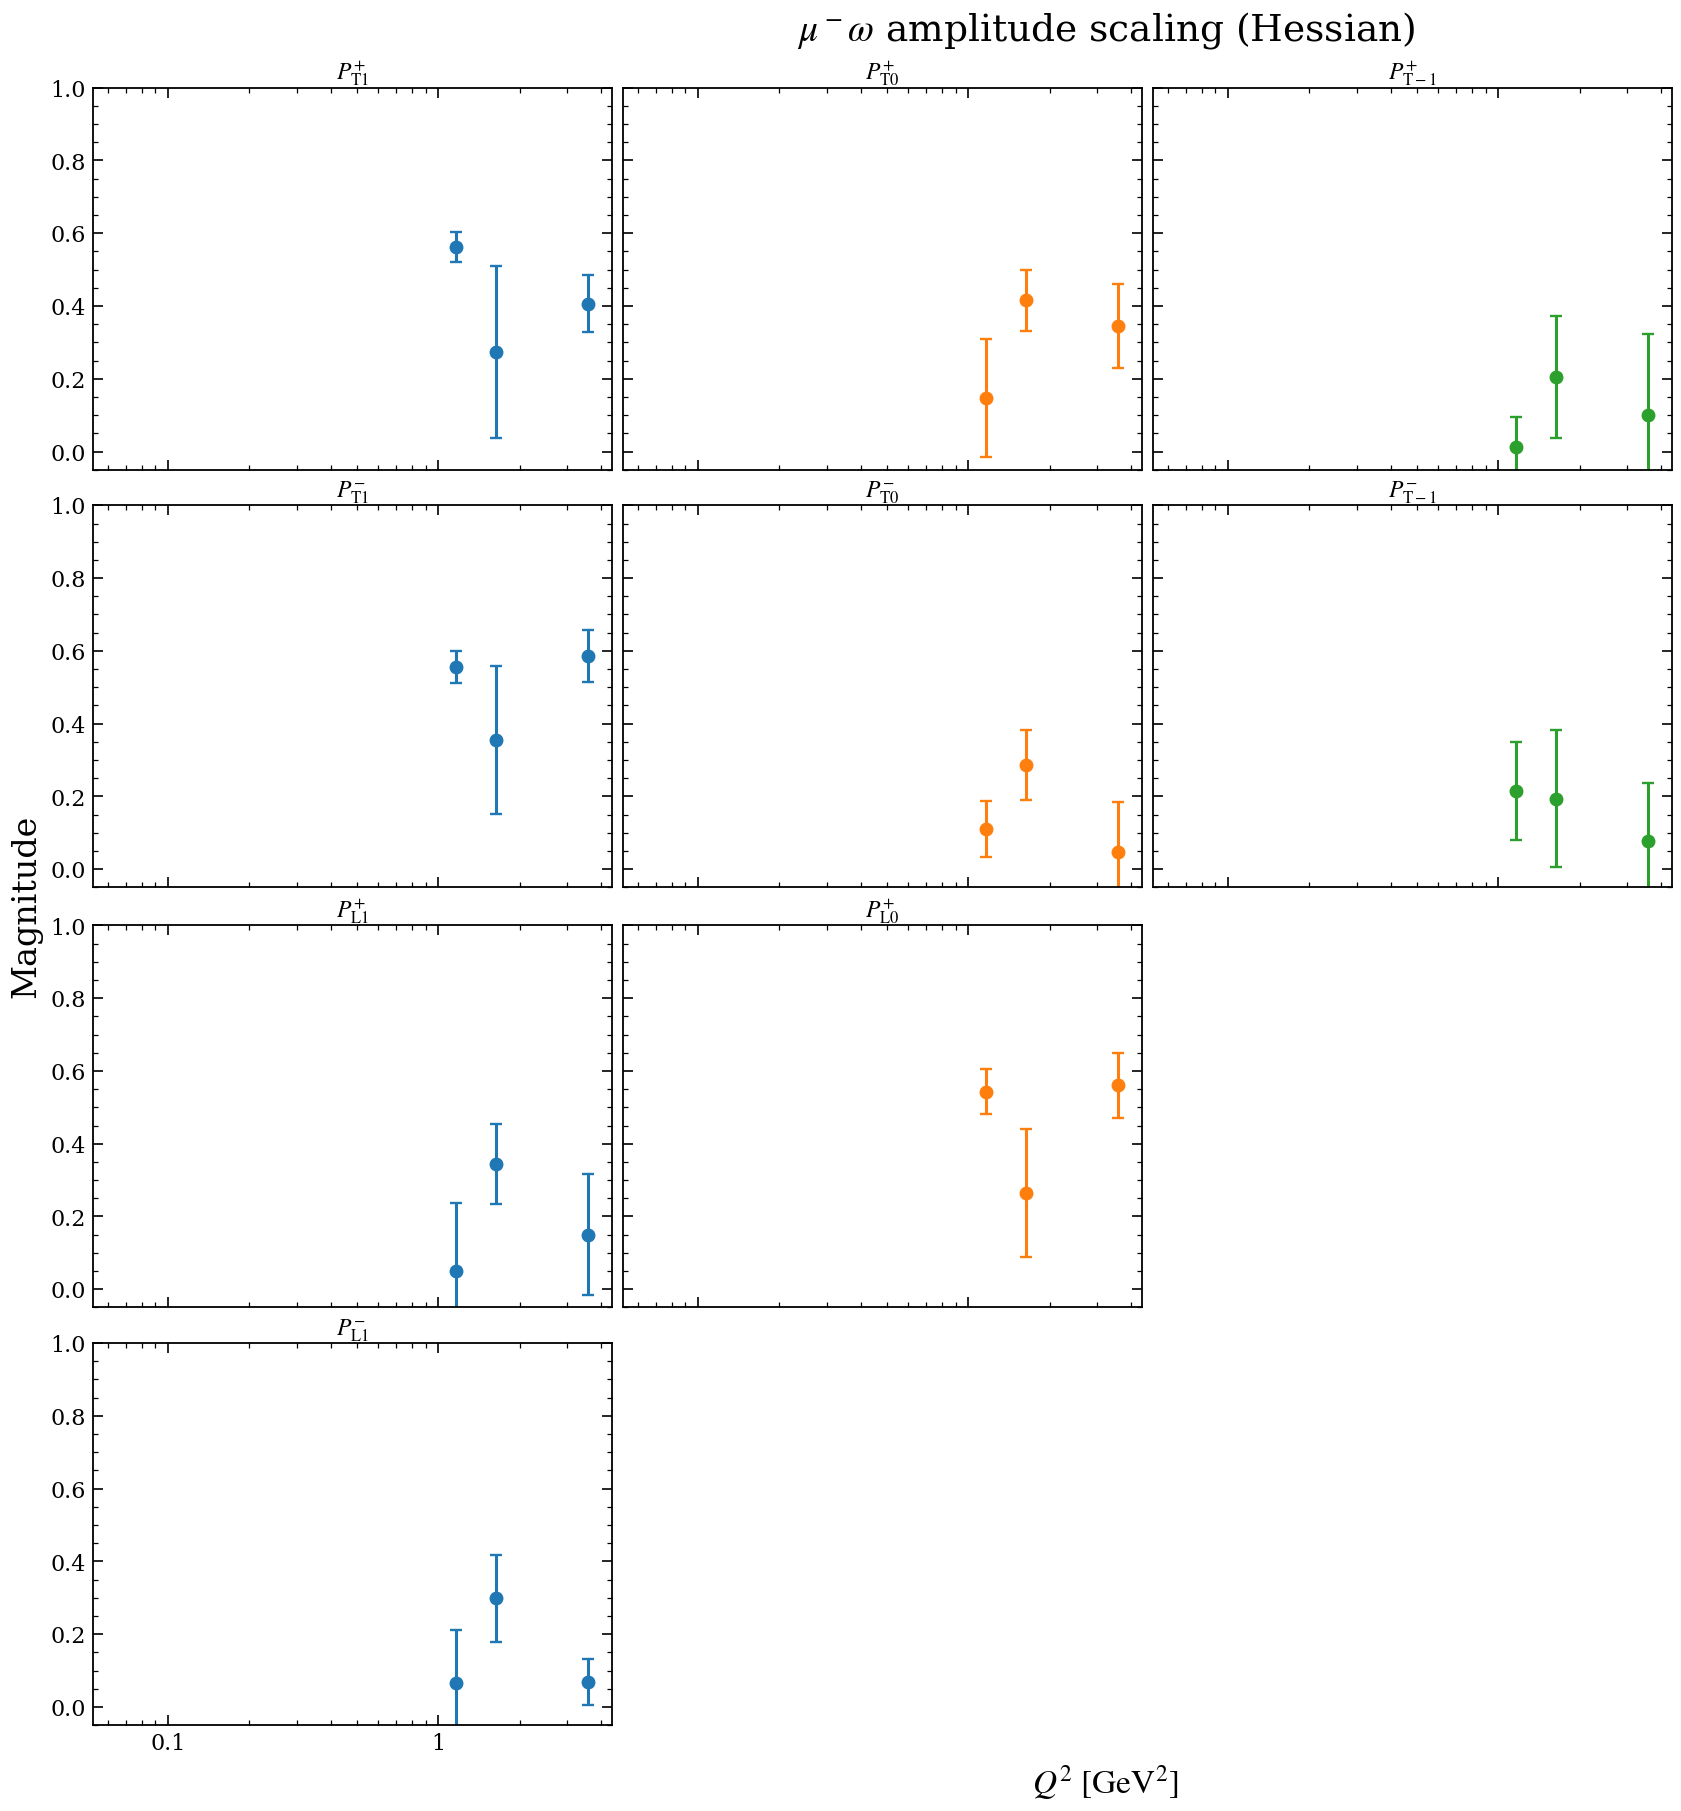

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/mu_omega_hessian_scaling_poster.png


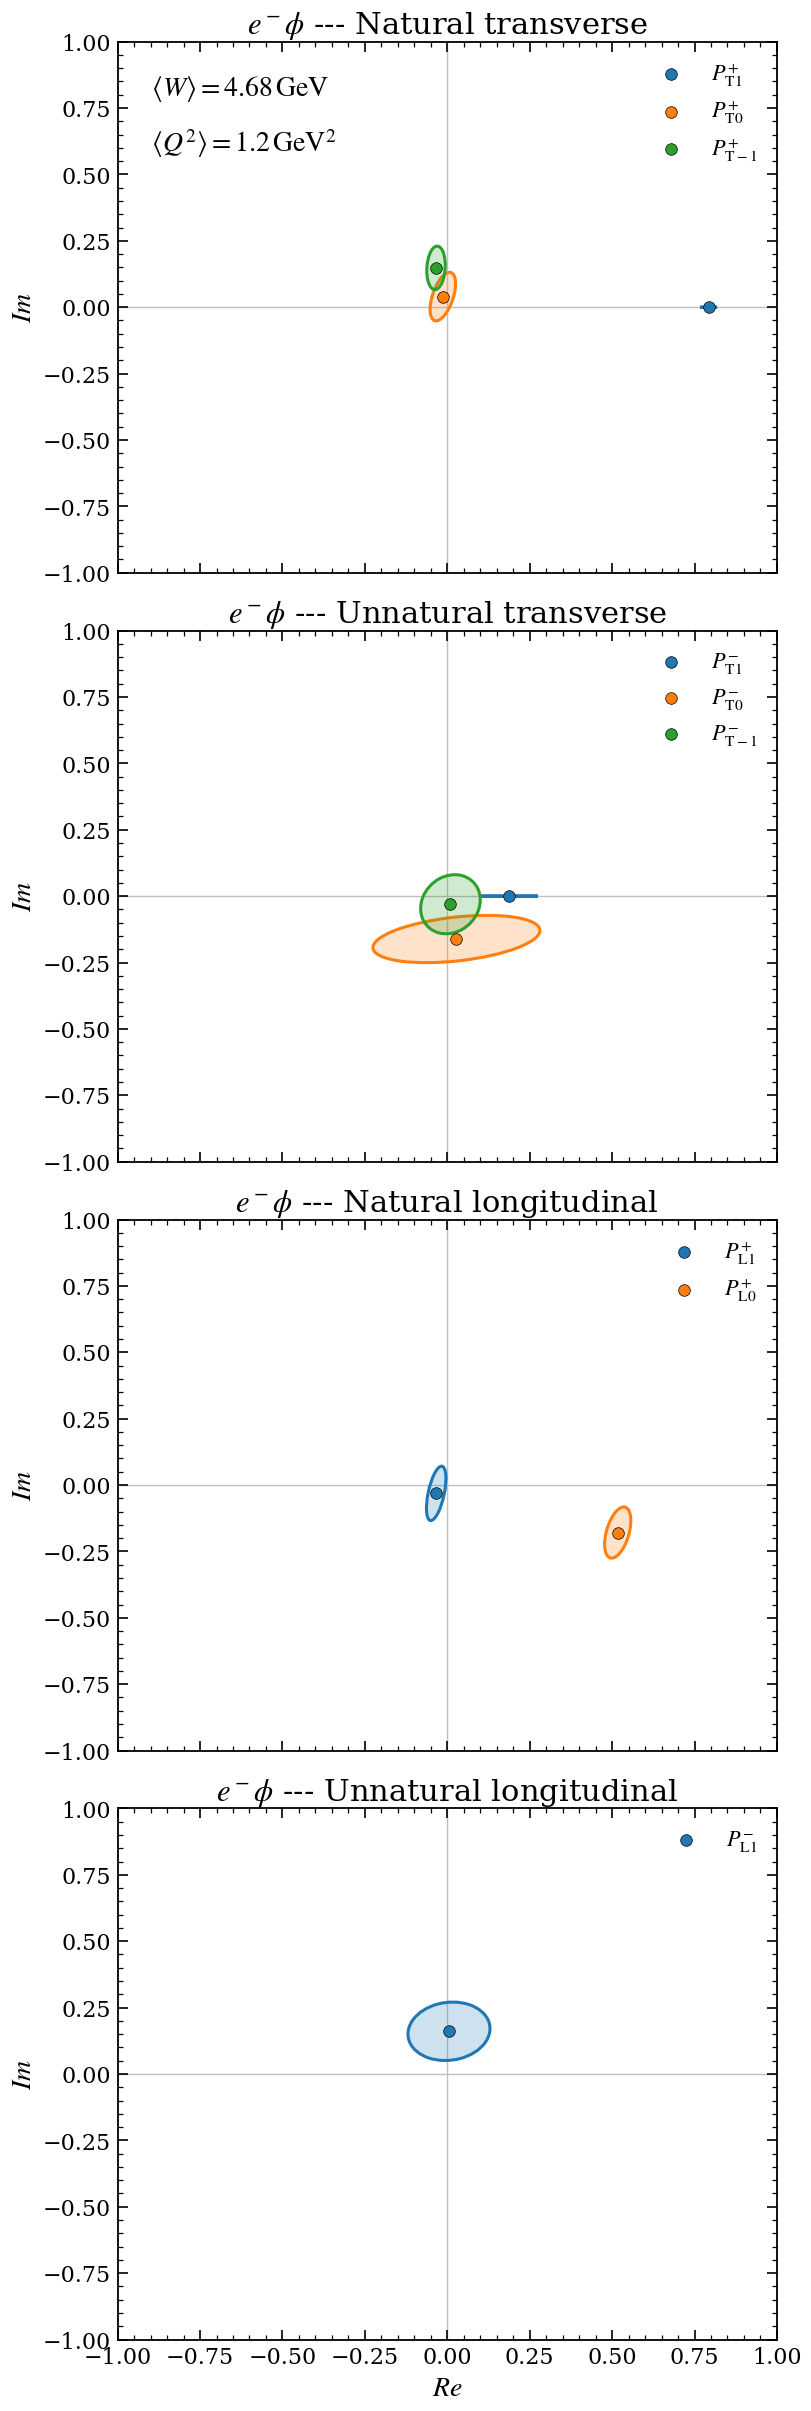

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_phi/ElPhi_results_0_hessian_argand_poster.pdf


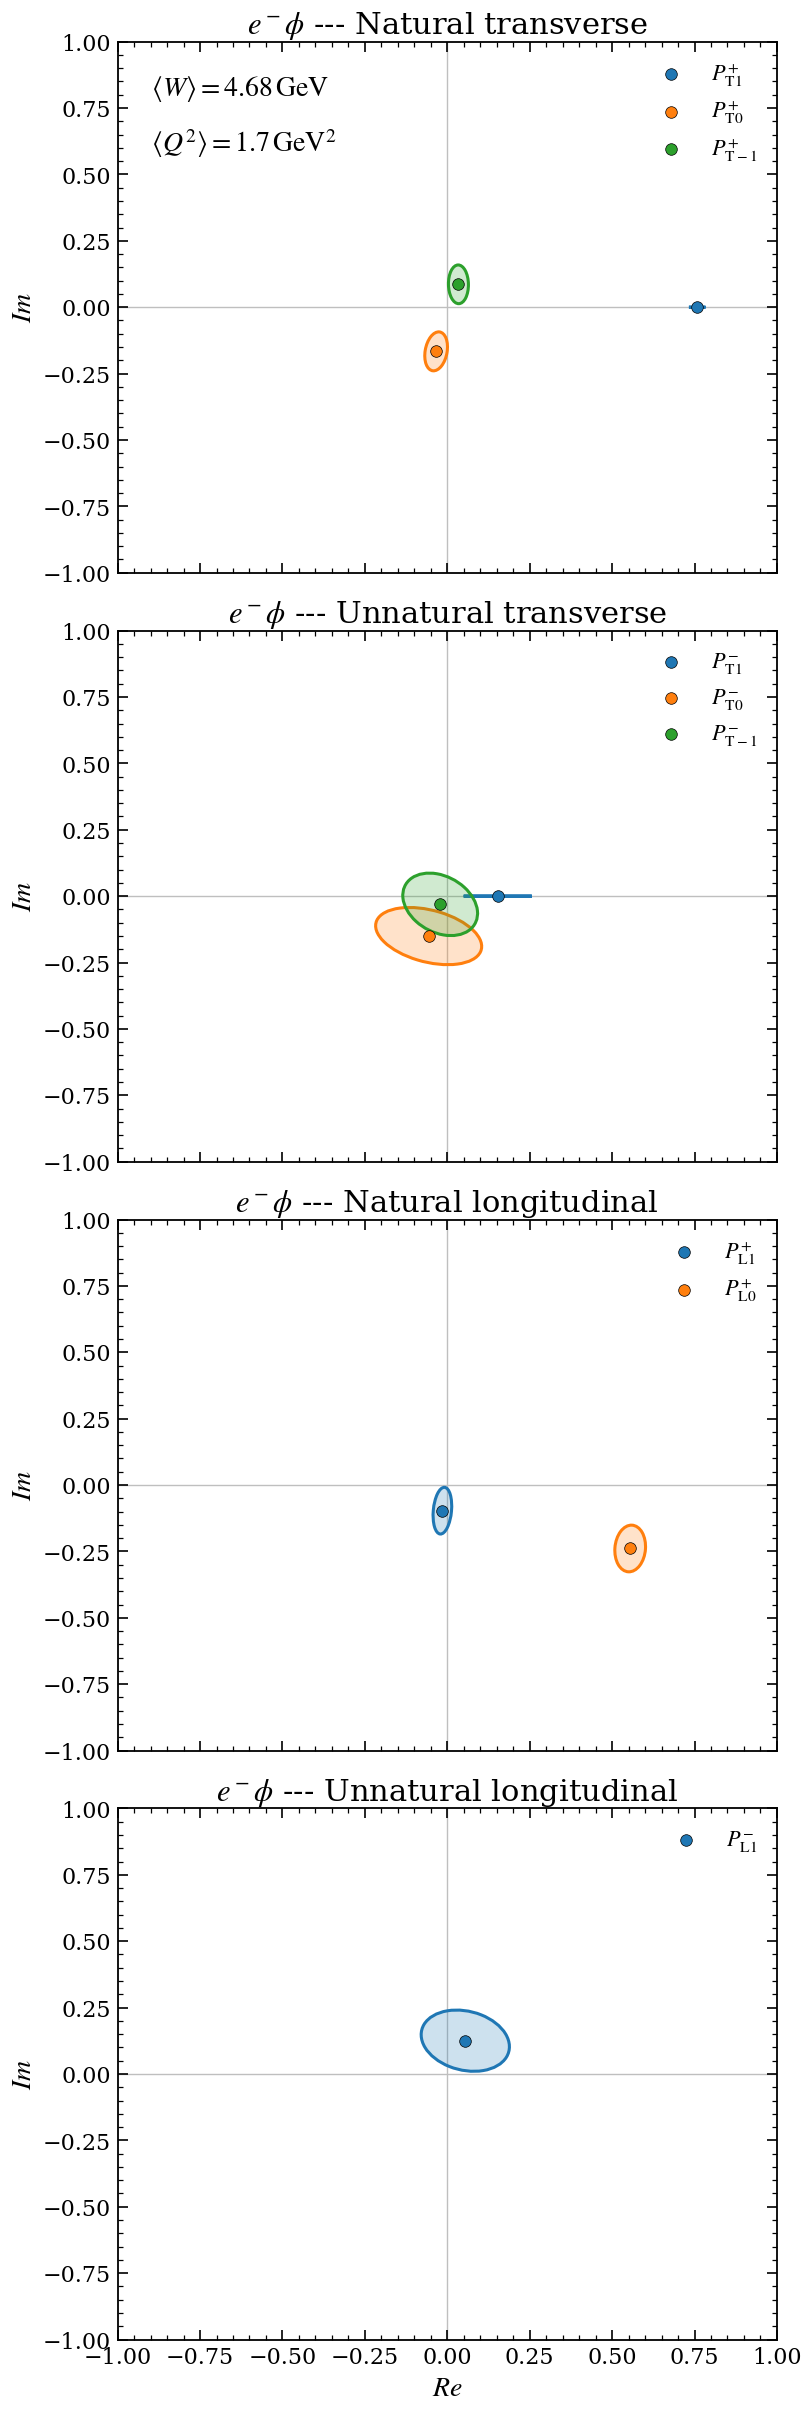

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_phi/ElPhi_results_1_hessian_argand_poster.pdf


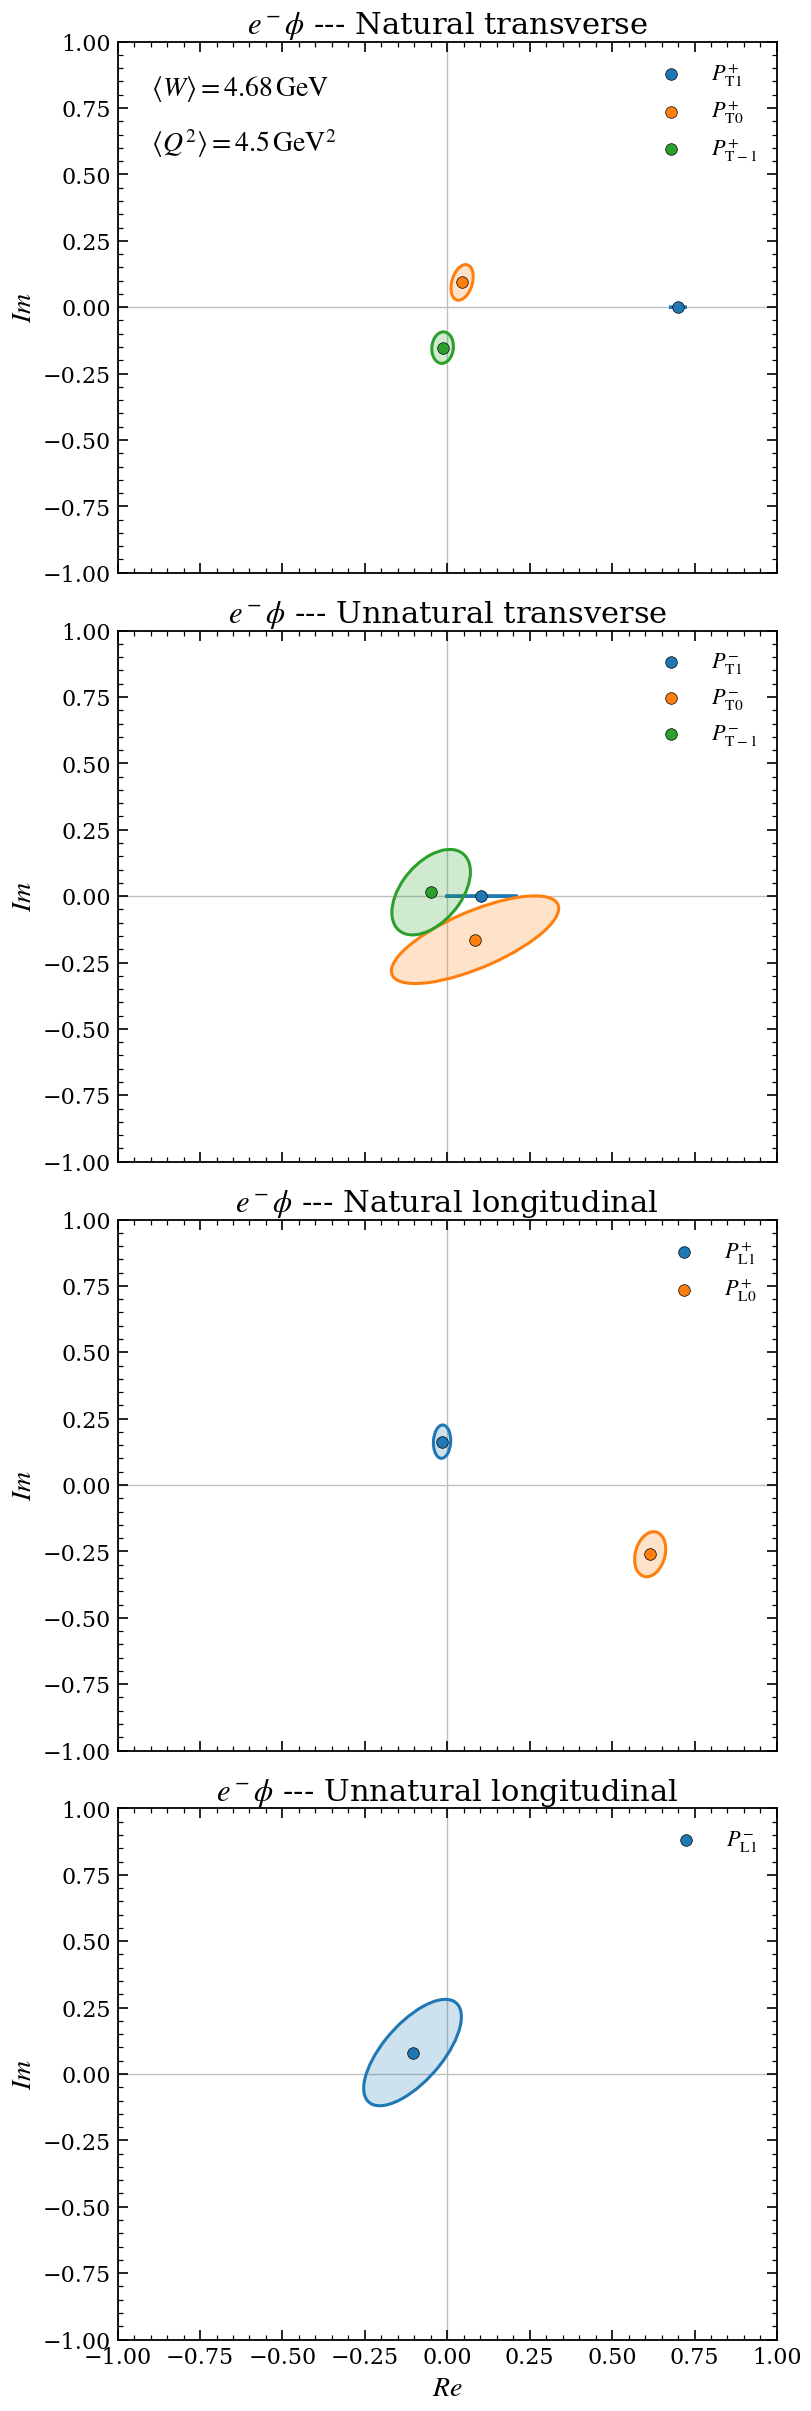

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_phi/ElPhi_results_2_hessian_argand_poster.pdf


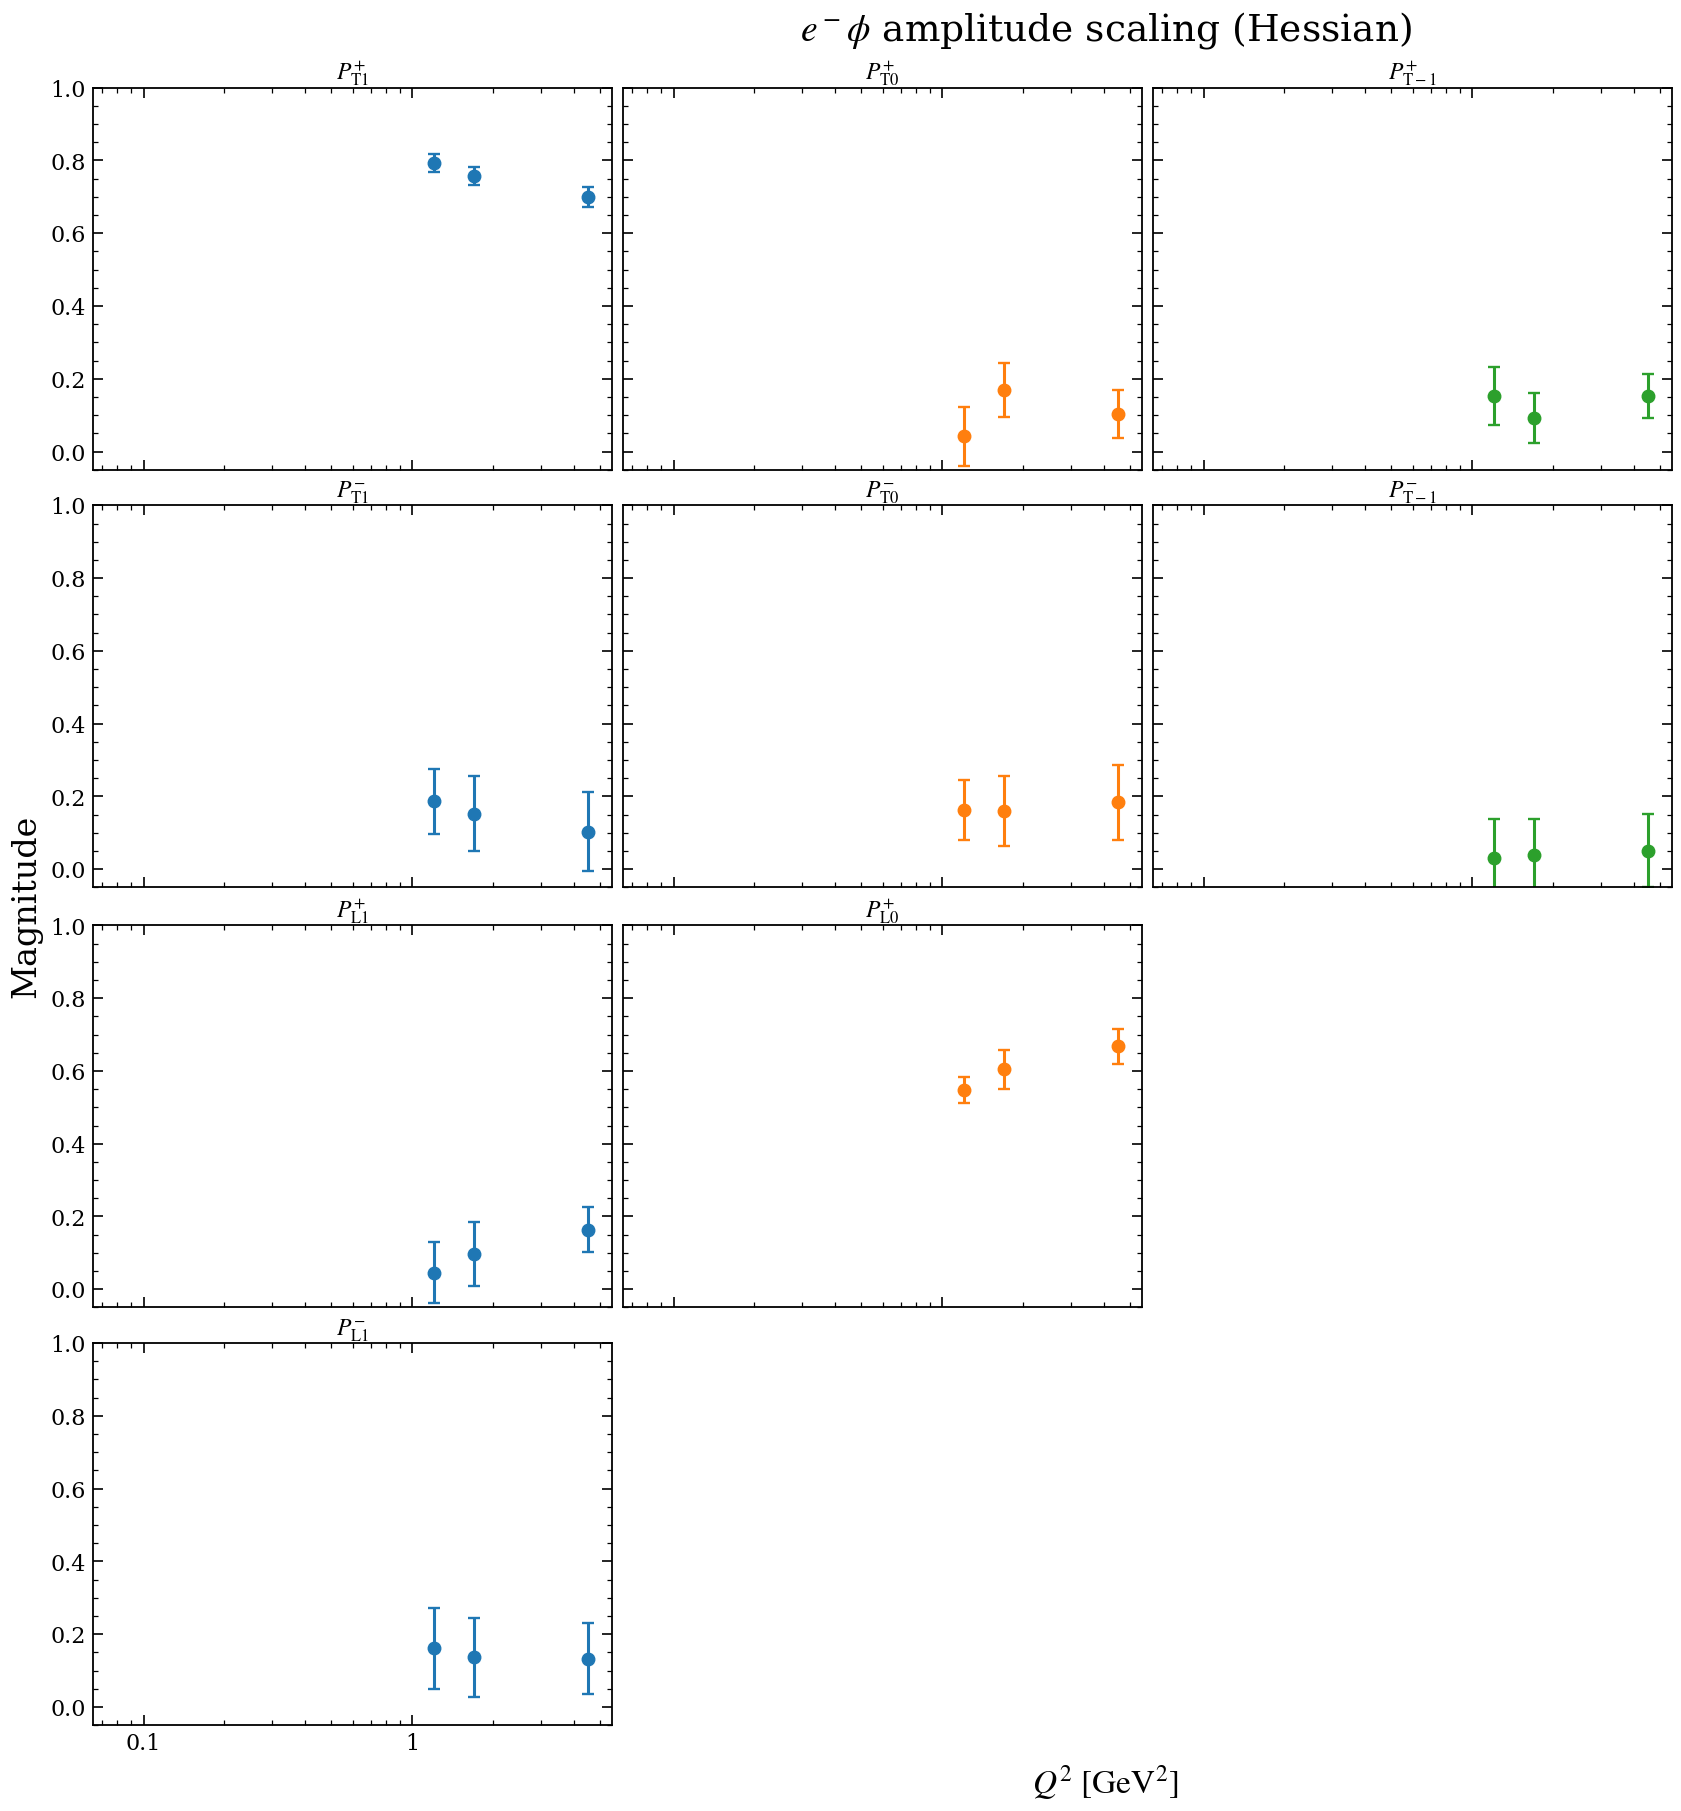

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/hessian_HERMES_outputs/e_phi_hessian_scaling_poster.png


,channel,_bin,_q2,_entries,_best_index,_objective
0,e_rho,0,0.82,100000,11209,2.566646
1,e_rho,1,1.19,100000,16657,4.205712
2,e_rho,2,1.66,100000,6218,3.876879
3,e_rho,3,3.06,100000,82542,8.371539
4,mu_rho,0,1.14,100000,82110,1.685147
5,mu_rho,1,1.60,100000,20265,7.770100
6,mu_rho,2,2.80,100000,1749,14.223758
7,mu_rho,3,6.02,100000,11986,7.775015
8,e_omega,0,1.28,100000,36181,8.810241
9,e_omega,1,2.00,100000,80722,3.124233


In [9]:
def result_file(channel, bin_index):
    return OUTPUT_DIR / f"{channel['prefix']}_results_{bin_index}.root"


def skip_wave(name):
    return ((name.startswith("b_L") and name.endswith("_0"))
            or (name.startswith(("a_L", "b_L")) and name.endswith("_m1")) or (name.endswith("_0_0")))


def read_channel_minima(channel):
    rows = []
    for bin_index, q2 in enumerate(channel["q2"]):
        path = result_file(channel, bin_index)
        frame = read_fit_file(path, TREE_NAME)
        best_index, best, objective = select_best_minimum(
            frame, require_accurate_covariance=REQUIRE_ACCURATE_COVARIANCE
        )
        best["_bin"] = bin_index
        best["_q2"] = q2
        best["_entries"] = len(frame)
        best["_best_index"] = best_index
        best["_objective"] = float(best[objective])
        rows.append(best)
    return pd.DataFrame(rows)


def plot_phase_magnitude_argand(channel, minima):
    cmap = mpl.colormaps["tab10"]
    for _, best in minima.iterrows():
        q2 = float(best["_q2"])
        bin_index = int(best["_bin"])
        fig, axes = plt.subplots(4, 2, figsize=(16, 20), constrained_layout=True)
        for group in range(4):
            for wave_index in range(4):
                position = wave_index + 4 * group
                magnitude_name = MAGNITUDES[position]
                phase_name = PHASES[position]
                if magnitude_name not in best or phase_name not in best:
                    continue
                magnitude = float(best[magnitude_name])
                phase = float(best[phase_name])
                covariance_mag_phase = covariance_matrix(best, [magnitude_name, phase_name])
                color = cmap(wave_index)

                add_covariance_ellipse(
                    axes[group, 0], (phase, magnitude),
                    covariance_mag_phase[[1, 0]][:, [1, 0]], color,
                )
                axes[group, 0].scatter(phase, magnitude, s=60, color=color,
                                       edgecolor="black", linewidth=0.5)

                centre = (magnitude * np.cos(phase), magnitude * np.sin(phase))
                covariance_xy = transformed_argand_covariance(
                    magnitude, phase, covariance_mag_phase
                )
                add_covariance_ellipse(axes[group, 1], centre, covariance_xy, color)
                axes[group, 1].scatter(*centre, s=60, color=color,
                                       edgecolor="black", linewidth=0.5,
                                       label=wave_label(magnitude_name))

            axes[group, 0].set_xlim(-np.pi, np.pi)
            axes[group, 0].set_ylim(-0.05, 1.0)
            axes[group, 1].set_xlim(-1.0, 1.0)
            axes[group, 1].set_ylim(-1.0, 1.0)
            axes[group, 0].set_ylabel(r"Magnitude $|A|$")
            axes[group, 1].set_ylabel(r"Imaginary part $\operatorname{Im}A$")
            axes[group, 1].axhline(0, color="0.75", lw=1, zorder=0)
            axes[group, 1].axvline(0, color="0.75", lw=1, zorder=0)
            axes[group, 0].set_title(GROUP_TITLES[group])
            axes[group, 1].set_title(GROUP_TITLES[group])
            axes[group, 1].legend(frameon=False, ncol=2, fontsize=10)
            style_axis(axes[group, 0])
            style_axis(axes[group, 1])
        axes[-1, 0].set_xlabel(r"Phase $\varphi$ [rad]")
        axes[-1, 1].set_xlabel(r"Real part $\operatorname{Re}A$")
        fig.suptitle(
            channel["title"]
            + rf", $\langle Q^2\rangle={q2:g}\,\mathrm{{GeV}}^2$; ",
            fontsize=23,
        )
        output = FIGURE_DIR / channel["key"] / (
            f"{channel['prefix']}_results_{bin_index}_hessian_phase_argand.png"
        )
        save_figure(fig, output)


def plot_hessian_argand_summary(channel, minima):
    cmap = mpl.colormaps["tab10"]
    for _, best in minima.iterrows():
        q2 = float(best["_q2"])
        bin_index = int(best["_bin"])
        fig, axes = plt.subplots(4, 1, figsize=(8, 24), sharex=True,
                                 constrained_layout=True)
        axes[0].text(0.05, 0.94,
                     rf"$\langle W\rangle={channel['W']:.2f}\,\mathrm{{GeV}}$",
                     transform=axes[0].transAxes, fontsize=20, va="top")
        axes[0].text(0.05, 0.84,
                     rf"$\langle Q^2\rangle={q2:g}\,\mathrm{{GeV}}^2$",
                     transform=axes[0].transAxes, fontsize=20, va="top")
        for group in range(4):
            for wave_index in range(3):
                position = wave_index + 4 * group
                mag_name = MAGNITUDES[position]
                phase_name = PHASES[position]
                if skip_wave(mag_name) or mag_name not in best or phase_name not in best:
                    continue
                magnitude = float(best[mag_name])
                phase = float(best[phase_name])
                centre = (magnitude * np.cos(phase), magnitude * np.sin(phase))
                covariance_xy = transformed_argand_covariance(
                    magnitude, phase, covariance_matrix(best, [mag_name, phase_name])
                )
                color = cmap(wave_index)
                add_covariance_ellipse(axes[group], centre, covariance_xy, color)
                axes[group].scatter(*centre, s=70, color=color, edgecolor="black",
                                    linewidth=0.5, label=wave_label(mag_name), zorder=5)
            axes[group].set_xlim(-1, 1)
            axes[group].set_ylim(-1, 1)
            axes[group].set_title(channel["title"] + " --- " + GROUP_TITLES[group])
            axes[group].set_ylabel(r"$\operatorname{{Im}}$")
            axes[group].axhline(0, color="0.75", lw=1, zorder=0)
            axes[group].axvline(0, color="0.75", lw=1, zorder=0)
            axes[group].legend(frameon=False, loc="upper right")
            style_axis(axes[group])
        axes[-1].set_xlabel(r"$\operatorname{{Re}}$")
        output = FIGURE_DIR / channel["key"] / (
            f"{channel['prefix']}_results_{bin_index}_hessian_argand_poster.pdf"
        )
        save_figure(fig, output)


def plot_amplitude_scaling(channel, minima):
    # This retains the established HERMES 4x4 amplitude-scaling block.
    cmap = mpl.colormaps["tab10"]
    fig, axes = plt.subplots(4, 4, figsize=(22, 18), sharex=True, sharey=True,
                             constrained_layout=True)
    q2 = minima["_q2"].to_numpy(dtype=float)
    for group in range(4):
        for wave_index in range(4):
            position = wave_index + 4 * group
            name = MAGNITUDES[position]
            ax = axes[group, wave_index]
            if skip_wave(name) or name not in minima:
                ax.set_visible(False)
                continue
            values = minima[name].to_numpy(dtype=float)
            errors = minima[f"err__{name}"].to_numpy(dtype=float)
            ax.errorbar(q2, values, yerr=errors, fmt="o", markersize=9,
                        elinewidth=2.2, capsize=4, capthick=1.7,
                        color=cmap(wave_index))
            ax.set_ylim(-0.05, 1.0)
            if len(q2) > 1:
                ax.set_xscale("log")
            ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:g}"))
            ax.set_title(wave_label(name), fontsize=17)
            style_axis(ax)
    fig.suptitle(channel["title"] + " amplitude scaling (Hessian)", fontsize=27)
    fig.supylabel(r"Magnitude", fontsize=24)
    fig.supxlabel(r"$Q^2\ [\mathrm{{GeV}}^2]$", fontsize=24)
    output = FIGURE_DIR / f"{channel['key']}_hessian_scaling_poster.png"
    save_figure(fig, output)


all_summaries = []
for channel in CHANNELS:
    minima = read_channel_minima(channel)
    out_dir = FIGURE_DIR / channel["key"]
    out_dir.mkdir(parents=True, exist_ok=True)
    # plot_phase_magnitude_argand(channel, minima)
    plot_hessian_argand_summary(channel, minima)
    plot_amplitude_scaling(channel, minima)
    all_summaries.append(minima.assign(channel=channel["key"]))

combined = pd.concat(all_summaries, ignore_index=True)
display(combined[["channel", "_bin", "_q2", "_entries", "_best_index", "_objective"]])
